# Customer Segmentation for Targeted Marketing Campaigns

## FinTech Solutions S.p.A.

**Project objective:**  
This project aims to develop a customer segmentation model based on data related to credit card holders of **FinTech Solutions S.p.A.**, a company operating in the financial services sector.

The segmentation will be carried out using **unsupervised clustering techniques**, with particular reference to the **K-Means** algorithm, in order to identify homogeneous groups of customers with similar behaviors.

The analysis mainly focuses on:

- customers’ spending behavior;
- credit card usage patterns;
- use of cash advances;
- purchase frequency;
- payment habits;
- credit limit and customer relationship tenure.

The final objective is to transform the clustering results into **targeted marketing strategies**, useful for personalizing offers, improving the effectiveness of promotional campaigns, and optimizing the allocation of commercial resources.

## Project workflow

The project will be developed according to the following phases:

1. **Importing libraries and loading the dataset**
2. **Exploratory data analysis**
3. **Dataset quality check**
4. **Handling missing values**
5. **Analysis of distributions and outliers**
6. **Data preprocessing**
7. **Feature standardization**
8. **Choosing the optimal number of clusters**
9. **Applying the K-Means model**
10. **Cluster interpretation**
11. **Definition of targeted marketing strategies**
12. **Final conclusions**

## Importing Libraries and Loading the Dataset

**Objective:** import the required libraries and load the dataset in a flexible and reproducible way.

In this phase, the libraries used for data analysis, data visualization, preprocessing, and clustering are imported.

The dataset is then loaded into a DataFrame called `df`. The file name is defined through the variable `DATA_FILENAME`, while the actual file path is stored in `DATA_PATH`.

Before loading the dataset, the notebook searches for `credit_card_customers.csv` in common locations, such as the current working directory, the parent directory, and the Colab `/content` folder. If the file is not found and the notebook is running in Google Colab, the user is asked to upload it manually.

This approach makes the notebook more flexible across different environments, such as Google Colab, Jupyter Notebook, JupyterLab, or other Python-based tools.


In [421]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    adjusted_rand_score
)

In [422]:
DATA_FILENAME = "credit_card_customers.csv"

possible_paths = [
    Path(DATA_FILENAME),
    Path.cwd() / DATA_FILENAME,
    Path.cwd().parent / DATA_FILENAME,
    Path("/content") / DATA_FILENAME
]

DATA_PATH = None

for path in possible_paths:
    if path.exists():
        DATA_PATH = path
        break

if DATA_PATH is None:
    try:
        from google.colab import files

        print(f"File '{DATA_FILENAME}' not found.")
        print("Please upload the dataset file.")

        uploaded = files.upload()

        if DATA_FILENAME not in uploaded:
            raise FileNotFoundError(
                f"The uploaded file does not match the expected name: '{DATA_FILENAME}'."
            )

        DATA_PATH = Path(DATA_FILENAME)

    except ImportError:
        raise FileNotFoundError(
            f"File '{DATA_FILENAME}' not found. "
            "Place it in the same folder as the notebook, "
            "in the current working directory, or update DATA_PATH manually."
        )

df = pd.read_csv(DATA_PATH)

print("Dataset successfully loaded.")
print(f"File used: {DATA_PATH.resolve()}")
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

display(df.head())

Dataset successfully loaded.
File used: /content/credit_card_customers.csv
Number of rows: 8950
Number of columns: 18


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


# Initial Exploratory Analysis of the Dataset

## Dimensions, Columns, and Data Types

**Objective:** analyze the initial structure of the dataset.

In this phase, the number of observations and variables in the dataset, the column names, and the data type associated with each variable are checked.

This check is useful to verify that the dataset has been loaded correctly and to distinguish the identifier variable `CUST_ID` from the numerical variables that can be used in the subsequent phases of analysis and clustering.

In [423]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nInfo:")
df.info()

Shape: (8950, 18)

Columns:
Index(['CUST_ID', 'BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY',
       'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE'],
      dtype='object')

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES     

### Observations on the Results

The analysis shows that the dataset contains **8,950 observations** and **18 columns**. The variable `CUST_ID` is textual and represents the unique customer identifier, while the remaining variables are numerical.

The presence of numerical variables makes the dataset suitable for the application of clustering techniques, after an appropriate preprocessing phase. Furthermore, from the non-null values check, it can be observed that some columns contain missing values, which will be analyzed in more detail in the next section.

## Initial Descriptive Statistics

**Objective:** obtain a first quantitative summary of the numerical variables in the dataset.

In this phase, the main descriptive statistics are analyzed, such as mean, standard deviation, minimum and maximum values, and quartiles.

This check makes it possible to identify differences in scale between variables, potential extreme values, and initial indications about the distribution of the data.

In [424]:
df.describe()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


### Observations on the Results

The descriptive statistics show that the variables in the dataset have very different scales. Some columns, such as `BALANCE`, `PURCHASES`, `CASH_ADVANCE`, `CREDIT_LIMIT`, `PAYMENTS`, and `MINIMUM_PAYMENTS`, contain monetary values that can be very high.

Other variables, such as `BALANCE_FREQUENCY`, `PURCHASES_FREQUENCY`, `CASH_ADVANCE_FREQUENCY`, and `PRC_FULL_PAYMENT`, instead represent frequencies or percentages. Most of these variables take values between 0 and 1, although `CASH_ADVANCE_FREQUENCY` has a maximum value greater than 1, which will be examined in more detail in the following phases.

These differences confirm the need to apply a preprocessing and standardization phase before clustering, in order to prevent variables with larger values from excessively influencing the model.

## Checking Missing Values

**Objective:** verify the presence of missing values in the dataset columns.

In this phase, the number of missing values is calculated for each variable. This check is necessary because the presence of null values can affect the subsequent phases of analysis, preprocessing, and clustering.

In [425]:
df.isnull().sum()

,0
CUST_ID,0
BALANCE,0
BALANCE_FREQUENCY,0
PURCHASES,0
ONEOFF_PURCHASES,0
INSTALLMENTS_PURCHASES,0
CASH_ADVANCE,0
PURCHASES_FREQUENCY,0
ONEOFF_PURCHASES_FREQUENCY,0
PURCHASES_INSTALLMENTS_FREQUENCY,0


### Observations on the Results

The check shows that the dataset contains missing values only in two variables: `CREDIT_LIMIT` and `MINIMUM_PAYMENTS`.

Specifically, `CREDIT_LIMIT` has **1 missing observation**, while `MINIMUM_PAYMENTS` has **313 missing observations**. All the other variables are complete.

This situation confirms the need to handle these values during the preprocessing phase, avoiding the removal of useful observations for the analysis.

## Percentage of Missing Values

**Objective:** assess the percentage weight of missing values compared to the total number of observations.

In this phase, the number of missing values is converted into a percentage, in order to understand how much the incompleteness of the variables actually affects the dataset.

In [426]:
(df.isnull().sum() / len(df)) * 100

,0
CUST_ID,0.000000
BALANCE,0.000000
BALANCE_FREQUENCY,0.000000
PURCHASES,0.000000
ONEOFF_PURCHASES,0.000000
INSTALLMENTS_PURCHASES,0.000000
CASH_ADVANCE,0.000000
PURCHASES_FREQUENCY,0.000000
ONEOFF_PURCHASES_FREQUENCY,0.000000
PURCHASES_INSTALLMENTS_FREQUENCY,0.000000


### Observations on the Results

The percentage analysis confirms that the level of incompleteness in the dataset is very limited.

The variable `CREDIT_LIMIT` has an almost negligible percentage of missing values, equal to approximately **0.01%** of the total. The variable `MINIMUM_PAYMENTS`, on the other hand, has approximately **3.50%** missing values.

Since the incidence of missing values is limited, they can be handled during the preprocessing phase without removing a significant number of observations.

## Checking Duplicates

**Objective:** verify the presence of duplicate rows and repeated customer identifiers.

In this phase, both possible duplicates in the entire dataset and duplicates in the `CUST_ID` variable are checked, since `CUST_ID` represents the unique identifier of each customer.

In [427]:
df.duplicated().sum()

np.int64(0)

In [428]:
df["CUST_ID"].duplicated().sum()

np.int64(0)

### Observations on the Results

The duplicate check did not identify either repeated rows in the dataset or duplicate values in the `CUST_ID` variable.

This confirms that each observation represents a distinct customer and that there are no duplications that could distort the exploratory analysis or the subsequent clustering techniques.

## Separating Numerical Variables

**Objective:** create a dataset containing only the numerical variables useful for the analysis.

In this phase, the `CUST_ID` variable is excluded because it only represents the customer identifier and does not contain behavioral information useful for clustering.

In [429]:
df_numeric = df.drop("CUST_ID", axis=1)
df_numeric.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


### Observations on the Results

The new DataFrame `df_numeric` contains only the numerical variables of the dataset, excluding `CUST_ID`.

This separation is necessary because clustering techniques work on quantitative variables and not on textual identifiers. In this way, the subsequent analyses will focus exclusively on the features useful for describing customer behavior.

## Checking the Available Numerical Variables

**Objective:** check how many numerical variables are present after excluding `CUST_ID`.

In this phase, the number of columns available in `df_numeric` and the list of variables that will be used in the subsequent analyses are verified.

In [430]:
print("Dimensions of df_numeric:")
print(df_numeric.shape)

print("\nColumns in df_numeric:")
print(df_numeric.columns.tolist())

Dimensions of df_numeric:
(8950, 17)

Columns in df_numeric:
['BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE']


## Checking Variables Expressed as Frequencies or Percentages

**Objective:** verify that the variables expressed as frequencies or percentages take values consistent with their nature.

In this phase, the minimum and maximum values of the variables that should take values between 0 and 1 are checked. This step makes it possible to identify any anomalies in the data before the preprocessing phase.

In [431]:
# List the variables that should have values between 0 and 1.
cols_01 = [
    "BALANCE_FREQUENCY",
    "PURCHASES_FREQUENCY",
    "ONEOFF_PURCHASES_FREQUENCY",
    "PURCHASES_INSTALLMENTS_FREQUENCY",
    "CASH_ADVANCE_FREQUENCY",
    "PRC_FULL_PAYMENT"
]

# Check for each variable whether there are values outside the expected range.
for col in cols_01:
    print(f"Variable: {col}")
    print(f"Minimum value: {df[col].min()}")
    print(f"Maximum value: {df[col].max()}")
    print(f"Number of observations outside range [0, 1]: {((df[col] < 0) | (df[col] > 1)).sum()}")
    print("-" * 50)

Variable: BALANCE_FREQUENCY
Minimum value: 0.0
Maximum value: 1.0
Number of observations outside range [0, 1]: 0
--------------------------------------------------
Variable: PURCHASES_FREQUENCY
Minimum value: 0.0
Maximum value: 1.0
Number of observations outside range [0, 1]: 0
--------------------------------------------------
Variable: ONEOFF_PURCHASES_FREQUENCY
Minimum value: 0.0
Maximum value: 1.0
Number of observations outside range [0, 1]: 0
--------------------------------------------------
Variable: PURCHASES_INSTALLMENTS_FREQUENCY
Minimum value: 0.0
Maximum value: 1.0
Number of observations outside range [0, 1]: 0
--------------------------------------------------
Variable: CASH_ADVANCE_FREQUENCY
Minimum value: 0.0
Maximum value: 1.5
Number of observations outside range [0, 1]: 8
--------------------------------------------------
Variable: PRC_FULL_PAYMENT
Minimum value: 0.0
Maximum value: 1.0
Number of observations outside range [0, 1]: 0
-------------------------------------

### Observations on the Results

The range check shows that almost all frequency and percentage variables respect the expected interval between **0** and **1**.

The exception is the variable `CASH_ADVANCE_FREQUENCY`, which has a maximum value of **1.5** and **8 observations outside the expected range**. This anomaly indicates a slight inconsistency in the data, which will be handled in the subsequent preprocessing phase.

The other variables checked are consistent with their definition and do not present values outside the expected interval.

## Distribution of Numerical Variables

**Objective:** visualize the distribution of numerical variables through histograms.

In this phase, histograms of the quantitative variables are created to observe the shape of the distributions, the presence of values concentrated in specific areas, and possible extreme values.

This check is useful to understand whether data transformations are needed before applying the clustering model.

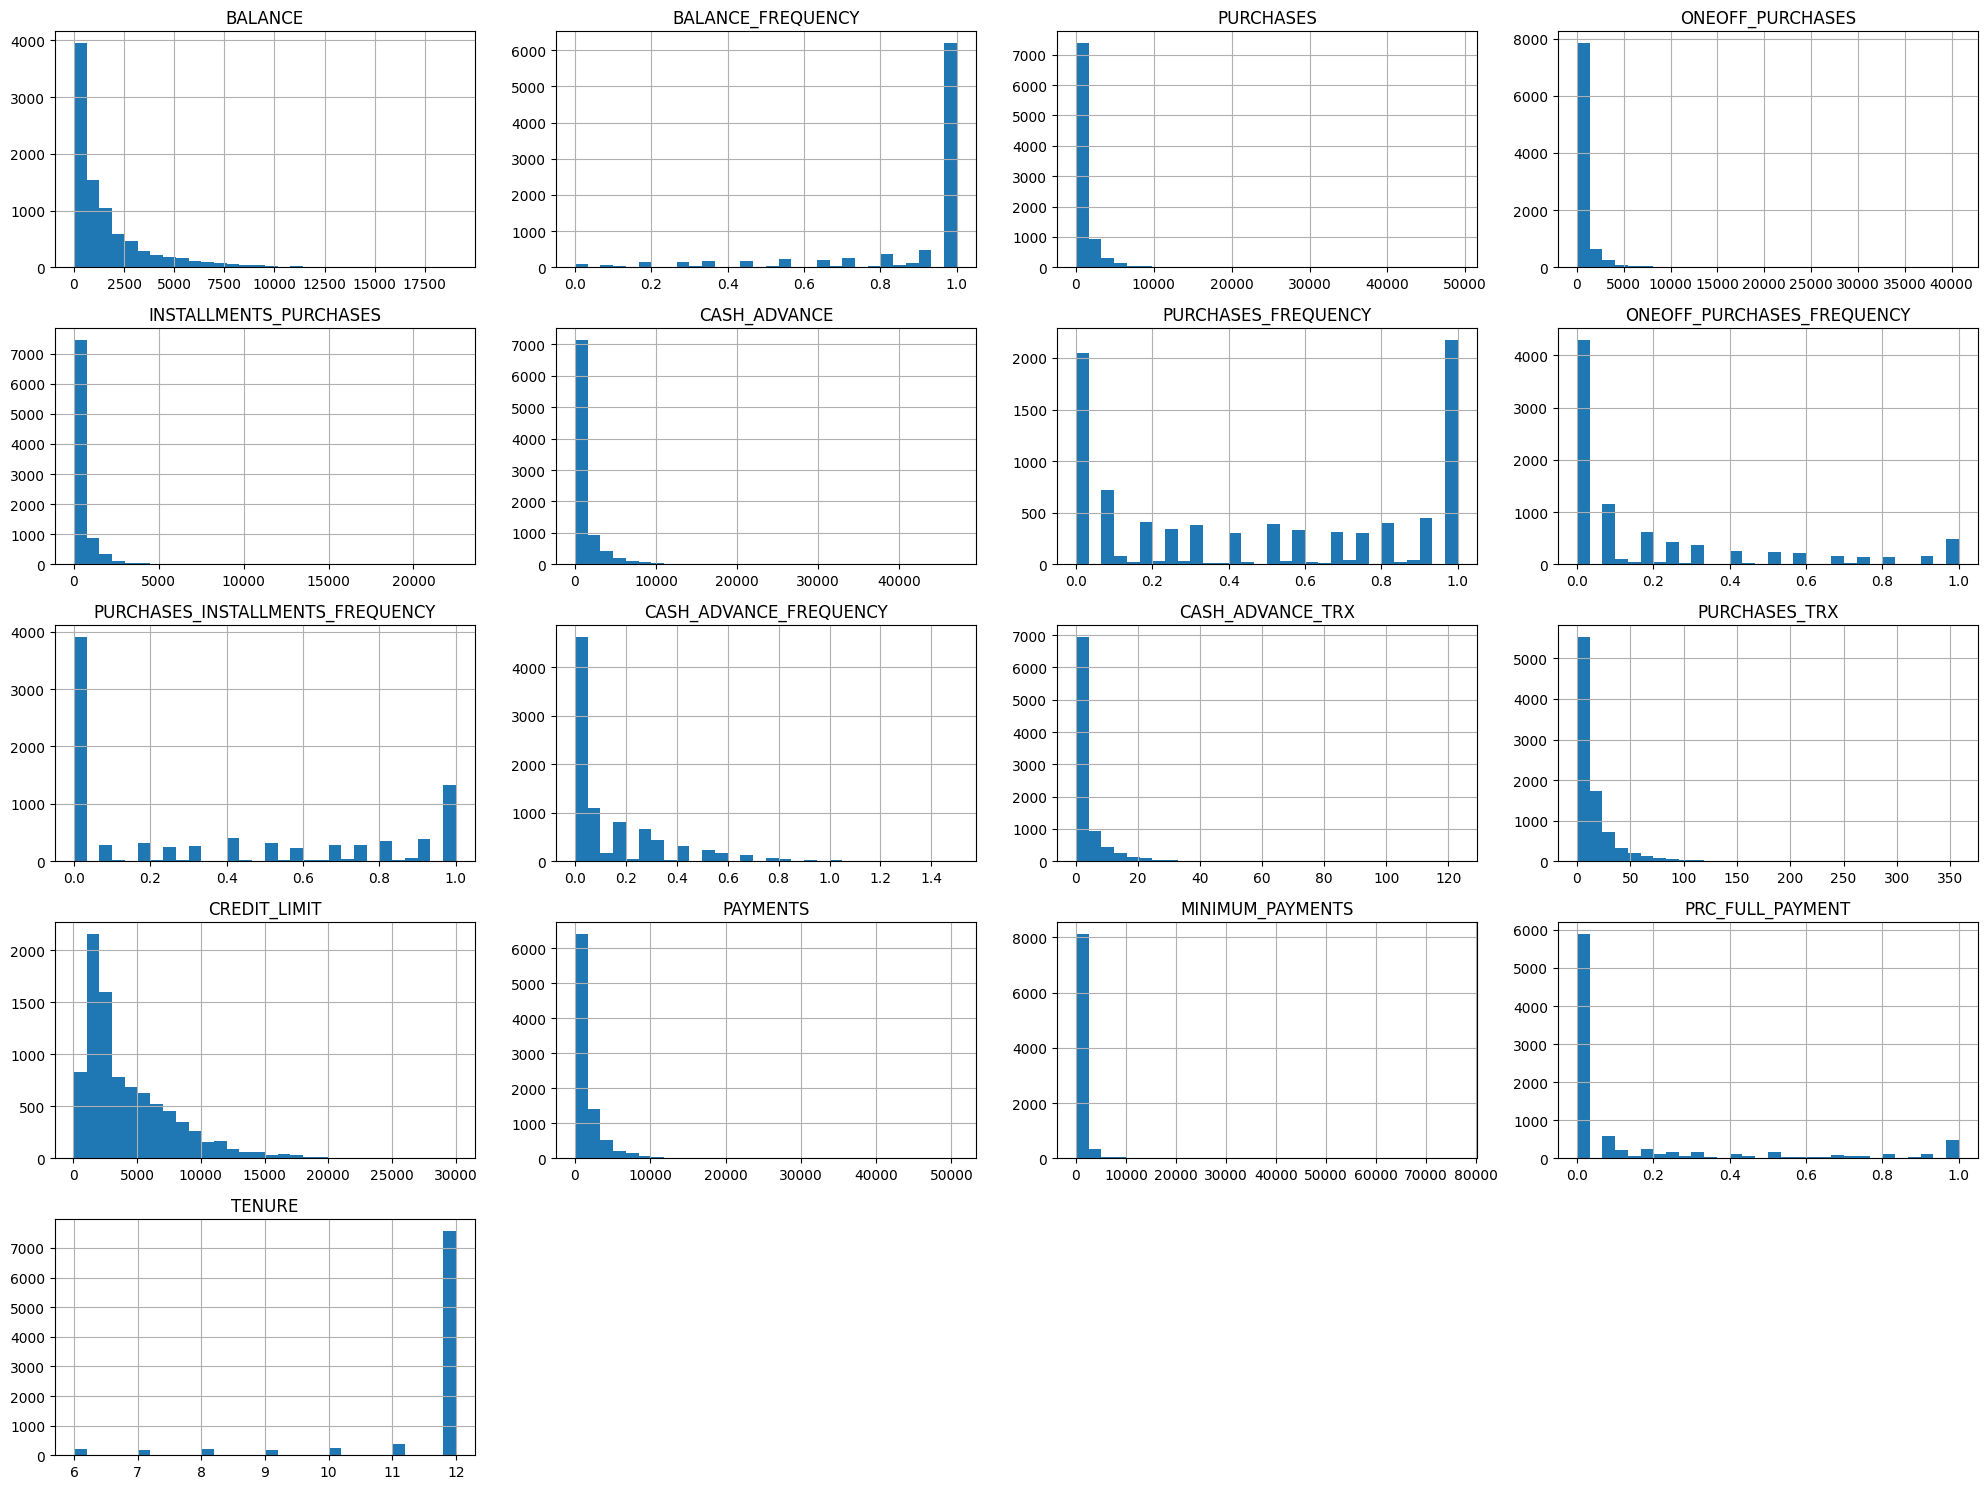

In [373]:
df_numeric.hist(figsize=(20, 15), bins=30)
plt.tight_layout()
plt.show()

### Observations on the Results

The graphical analysis shows that many numerical variables present strong positive skewness, with a high concentration of observations on low values and a long tail to the right.

This behavior is particularly evident in monetary variables, such as `BALANCE`, `PURCHASES`, `CASH_ADVANCE`, `PAYMENTS`, and `MINIMUM_PAYMENTS`, suggesting the presence of extreme values and a marked heterogeneity in customer behavior.

Frequency variables, on the other hand, are mainly concentrated between **0** and **1**, often with clear accumulations at the extremes. The variable `TENURE` shows a discrete distribution, with a strong concentration on the value **12**.

Overall, this analysis confirms the need to apply transformations and standardization in the following phases, in order to reduce the impact of outliers and make the variables more comparable with each other.

## Skewness of the Distributions

**Objective:** measure the degree of skewness of the numerical variables.

In this phase, skewness is calculated, which is an indicator that helps understand whether a distribution is symmetrical or skewed toward very high or very low values.

This check is useful to identify the variables that may require transformations before clustering.

In [374]:
skewness = df_numeric.skew().sort_values(ascending=False)
skewness

,0
MINIMUM_PAYMENTS,13.622797
ONEOFF_PURCHASES,10.045083
PURCHASES,8.144269
INSTALLMENTS_PURCHASES,7.299120
PAYMENTS,5.907620
CASH_ADVANCE_TRX,5.721298
CASH_ADVANCE,5.166609
PURCHASES_TRX,4.630655
BALANCE,2.393386
PRC_FULL_PAYMENT,1.942820


### Observations on the Results

The skewness values confirm that many variables present strong positive skewness. In particular, `MINIMUM_PAYMENTS`, `ONEOFF_PURCHASES`, `PURCHASES`, `INSTALLMENTS_PURCHASES`, `PAYMENTS`, `CASH_ADVANCE_TRX`, and `CASH_ADVANCE` show high values.

This result indicates that, for many variables, most customers are concentrated around low values, while only a few customers present much higher amounts or usage behaviors.

The variables `BALANCE_FREQUENCY` and `TENURE`, on the other hand, present negative skewness, indicating a higher concentration of observations toward high values.

This analysis reinforces the need to apply transformations, such as logarithmic transformation, and subsequently standardize the variables.

## Percentage of Zero Values

**Objective:** identify the variables with a high presence of zero values.

In this phase, the percentage of observations equal to zero is calculated for each numerical variable. This check is useful to understand which behaviors are not used by a significant portion of customers.

In [375]:
zero_percentage = (df_numeric.eq(0).sum() / len(df_numeric) * 100).sort_values(ascending=False)
zero_percentage.round(2)

,0
PRC_FULL_PAYMENT,65.96
CASH_ADVANCE_FREQUENCY,51.71
CASH_ADVANCE,51.71
CASH_ADVANCE_TRX,51.71
ONEOFF_PURCHASES_FREQUENCY,48.07
ONEOFF_PURCHASES,48.07
INSTALLMENTS_PURCHASES,43.75
PURCHASES_INSTALLMENTS_FREQUENCY,43.74
PURCHASES,22.84
PURCHASES_TRX,22.84


### Observations on the Results

The analysis of the percentage of zero values shows that some variables have a very high share of observations equal to zero.

This phenomenon is particularly evident for `PRC_FULL_PAYMENT`, `CASH_ADVANCE`, `CASH_ADVANCE_TRX`, and `ONEOFF_PURCHASES`, indicating that a significant portion of customers do not use certain card features or do not adopt specific payment behaviors.

This aspect is relevant for segmentation, as it can help distinguish groups of inactive or occasional customers, or customers characterized by very specific usage patterns.

## Visual Outlier Analysis Using Boxplots

**Objective:** visually identify the presence of extreme values in the numerical variables.

In this phase, several boxplots are created by dividing the variables into homogeneous groups: monetary variables, frequency or percentage variables, and count or customer relationship duration variables.

This division makes the charts more readable and allows for a clearer observation of the presence of outliers in the different types of variables.

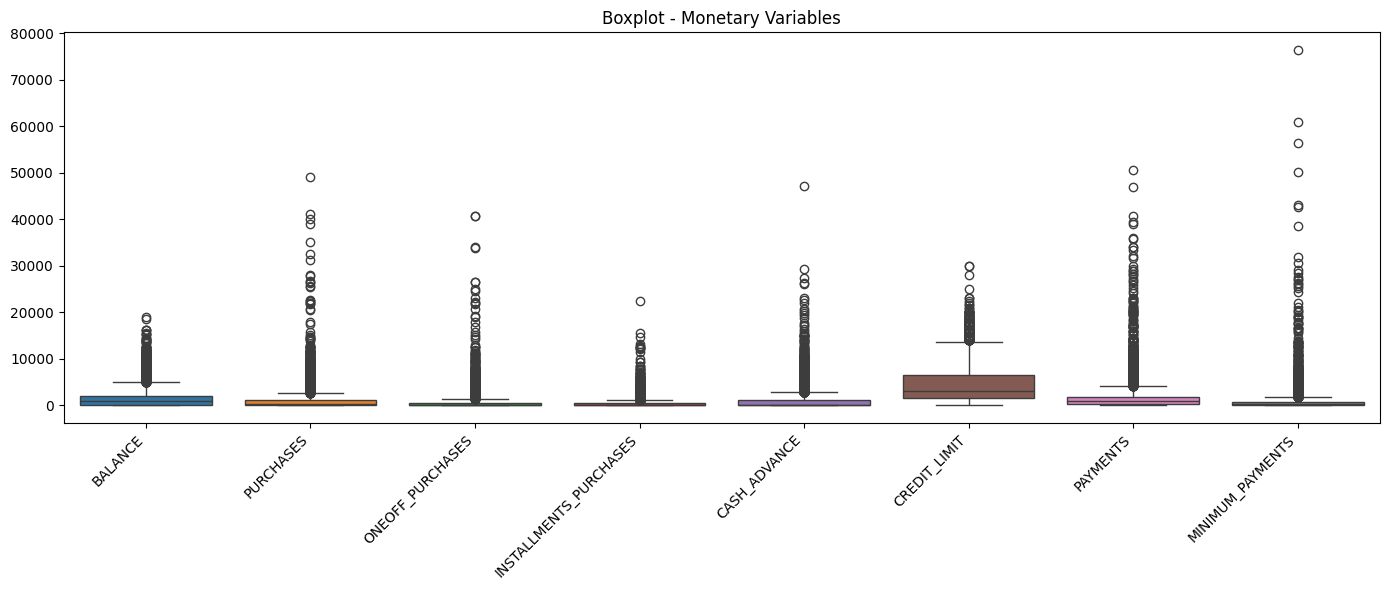

In [376]:
# Group 1: monetary variables
monetary_cols = [
    "BALANCE",
    "PURCHASES",
    "ONEOFF_PURCHASES",
    "INSTALLMENTS_PURCHASES",
    "CASH_ADVANCE",
    "CREDIT_LIMIT",
    "PAYMENTS",
    "MINIMUM_PAYMENTS"
]

plt.figure(figsize=(14, 6))
sns.boxplot(data=df_numeric[monetary_cols])
plt.title("Boxplot - Monetary Variables")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

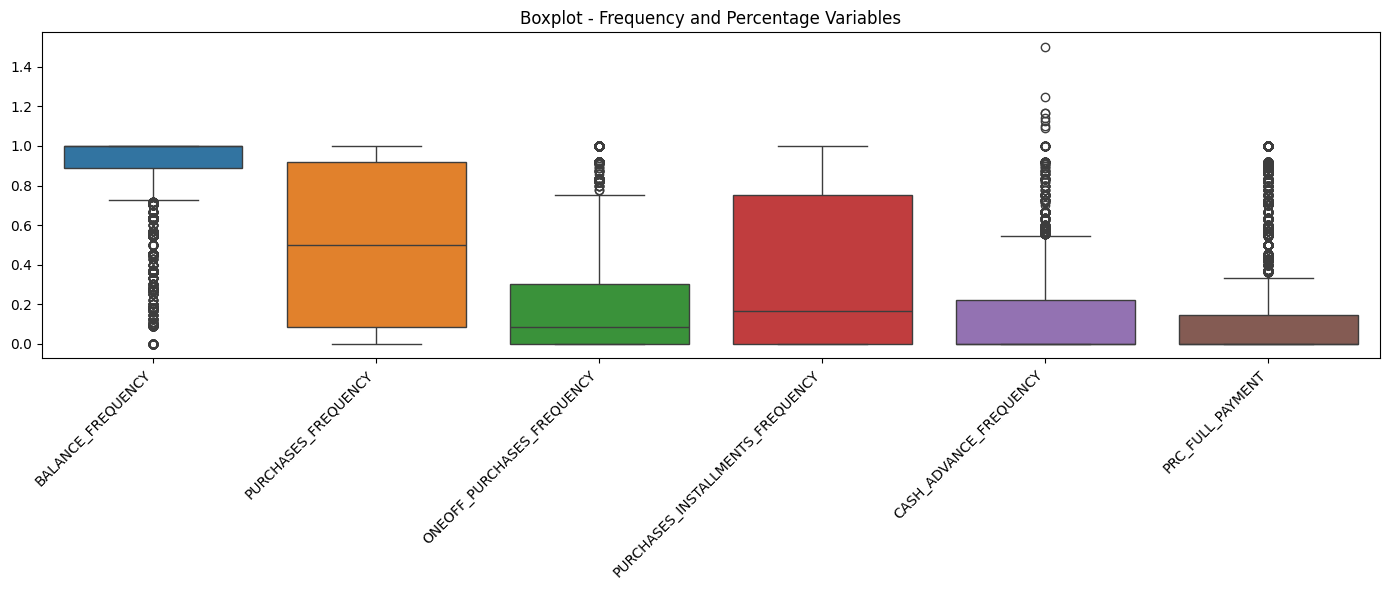

In [377]:
# Group 2: frequency and percentage variables
frequency_cols = [
    "BALANCE_FREQUENCY",
    "PURCHASES_FREQUENCY",
    "ONEOFF_PURCHASES_FREQUENCY",
    "PURCHASES_INSTALLMENTS_FREQUENCY",
    "CASH_ADVANCE_FREQUENCY",
    "PRC_FULL_PAYMENT"
]

plt.figure(figsize=(14, 6))
sns.boxplot(data=df_numeric[frequency_cols])
plt.title("Boxplot - Frequency and Percentage Variables")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

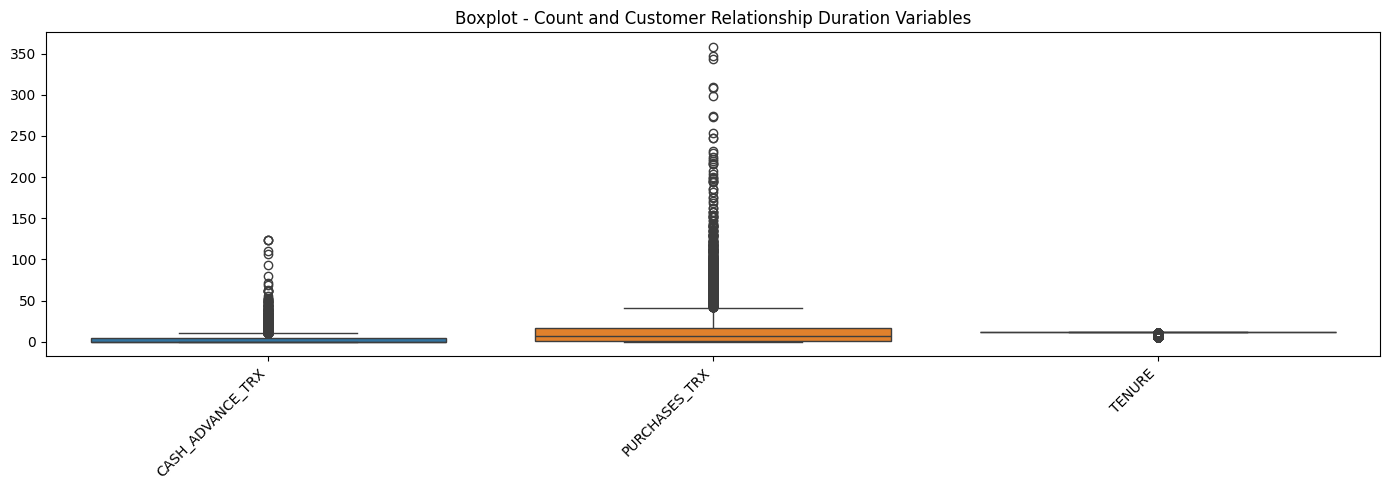

In [378]:
# Group 3: count and relationship duration variables
count_cols = [
    "CASH_ADVANCE_TRX",
    "PURCHASES_TRX",
    "TENURE"
]

plt.figure(figsize=(14, 5))
sns.boxplot(data=df_numeric[count_cols])
plt.title("Boxplot - Count and Customer Relationship Duration Variables")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Observations on the Results

The boxplot analysis confirms the presence of numerous extreme values in the dataset.

Outliers are particularly evident in monetary variables, such as `BALANCE`, `PURCHASES`, `CASH_ADVANCE`, `CREDIT_LIMIT`, `PAYMENTS`, and `MINIMUM_PAYMENTS`, which show strong dispersion and several very high values.

Count variables, especially `PURCHASES_TRX` and `CASH_ADVANCE_TRX`, also present relevant extreme values. Frequency and percentage variables, on the other hand, are easier to interpret when analyzed separately, since they have a different scale compared to monetary variables.

Overall, the boxplots confirm the need for a subsequent preprocessing phase, including transformation of the most skewed variables and standardization before applying clustering.

## Correlation Analysis Between Variables

**Objective:** observe the linear relationships between the numerical variables in the dataset.

In this phase, the correlation matrix is calculated and represented through a heatmap. This check makes it possible to identify variables that move in a similar way and possible groups of features related to the same customer behavior.

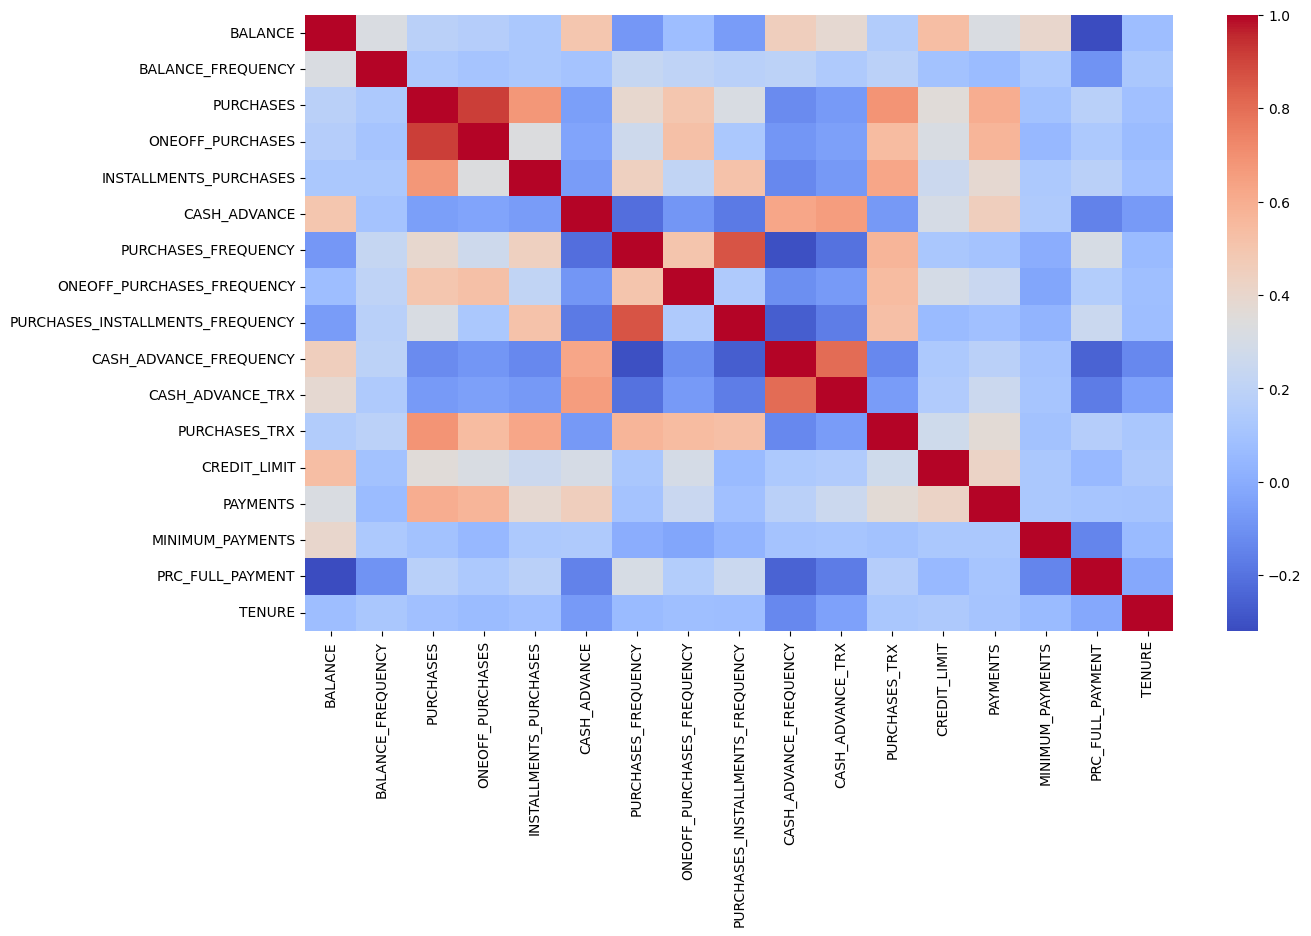

In [379]:
corr_matrix = df_numeric.corr()

plt.figure(figsize=(14, 8))
sns.heatmap(corr_matrix, cmap="coolwarm", annot=False)
plt.show()

## Numerical Values of the Correlation Matrix

**Objective:** display the correlation coefficients in numerical form.

After observing the heatmap, the correlation matrix is also shown in tabular format and rounded to two decimal places. This makes it possible to read the strength of the relationships between the variables more precisely.

In [380]:
corr_matrix.round(2)

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
BALANCE,1.00,0.32,0.18,0.16,0.13,0.50,-0.08,0.07,-0.06,0.45,0.39,0.15,0.53,0.32,0.40,-0.32,0.07
BALANCE_FREQUENCY,0.32,1.00,0.13,0.10,0.12,0.10,0.23,0.20,0.18,0.19,0.14,0.19,0.10,0.07,0.13,-0.10,0.12
PURCHASES,0.18,0.13,1.00,0.92,0.68,-0.05,0.39,0.50,0.32,-0.12,-0.07,0.69,0.36,0.60,0.09,0.18,0.09
ONEOFF_PURCHASES,0.16,0.10,0.92,1.00,0.33,-0.03,0.26,0.52,0.13,-0.08,-0.05,0.55,0.32,0.57,0.05,0.13,0.06
INSTALLMENTS_PURCHASES,0.13,0.12,0.68,0.33,1.00,-0.06,0.44,0.21,0.51,-0.13,-0.07,0.63,0.26,0.38,0.13,0.18,0.09
CASH_ADVANCE,0.50,0.10,-0.05,-0.03,-0.06,1.00,-0.22,-0.09,-0.18,0.63,0.66,-0.08,0.30,0.45,0.14,-0.15,-0.07
PURCHASES_FREQUENCY,-0.08,0.23,0.39,0.26,0.44,-0.22,1.00,0.50,0.86,-0.31,-0.20,0.57,0.12,0.10,0.00,0.31,0.06
ONEOFF_PURCHASES_FREQUENCY,0.07,0.20,0.50,0.52,0.21,-0.09,0.50,1.00,0.14,-0.11,-0.07,0.54,0.30,0.24,-0.03,0.16,0.08
PURCHASES_INSTALLMENTS_FREQUENCY,-0.06,0.18,0.32,0.13,0.51,-0.18,0.86,0.14,1.00,-0.26,-0.17,0.53,0.06,0.09,0.03,0.25,0.07
CASH_ADVANCE_FREQUENCY,0.45,0.19,-0.12,-0.08,-0.13,0.63,-0.31,-0.11,-0.26,1.00,0.80,-0.13,0.13,0.18,0.10,-0.25,-0.13


### Observations on the Results

The correlation matrix highlights significant relationships between variables belonging to the same behavioral area.

In particular, `PURCHASES` shows a positive correlation with `ONEOFF_PURCHASES`, `INSTALLMENTS_PURCHASES`, and `PURCHASES_TRX`, confirming that the total purchase amount is related to both one-off purchases and installment purchases.

`CASH_ADVANCE` is also associated with `CASH_ADVANCE_FREQUENCY` and `CASH_ADVANCE_TRX`, indicating a consistent relationship between the cash advance amount, usage frequency, and number of transactions.

The variable `PRC_FULL_PAYMENT`, on the other hand, shows negative correlations with some measures of credit exposure and usage, suggesting more cautious behavior among customers who fully pay their balance.

Overall, the heatmap and the numerical table confirm the presence of consistent behavioral structures, useful for the subsequent segmentation phase.

# Data Preprocessing

## Handling Missing Values and Correcting Data Inconsistencies

**Objective:** prepare the numerical dataset for the subsequent phases of transformation, standardization, and clustering.

In this phase, a working copy of the numerical dataset, called `df_prep`, is created in order to avoid directly modifying the original data.

Before imputing missing values, logical consistency checks are performed to identify and correct potential anomalies in the dataset. These include out-of-range frequency values, cases where `MINIMUM_PAYMENTS` is greater than `PAYMENTS`, and inconsistencies between transaction amounts and transaction counts.

After these corrections, the original missing values in `CREDIT_LIMIT` and `MINIMUM_PAYMENTS`, together with the inconsistent values in `PURCHASES_TRX` that were temporarily set to missing during the correction phase, are imputed using the median of the respective variables. This ensures that median imputation is applied only after correcting values that could distort the preprocessing and clustering phases.


In [381]:
df_prep = df_numeric.copy()

In [382]:
# Check logical inconsistencies before correction

df_check = df_numeric.copy()
tolerance = 0.01

inconsistency_check = pd.DataFrame({
    "Check": [
        "MINIMUM_PAYMENTS > PAYMENTS",
        "PURCHASES = 0 and PURCHASES_TRX > 0",
        "PURCHASES > 0 and PURCHASES_TRX = 0",
        "PURCHASES = 0 and PURCHASES_FREQUENCY > 0",
        "INSTALLMENTS_PURCHASES = 0 and PURCHASES_INSTALLMENTS_FREQUENCY > 0",
        "ONEOFF_PURCHASES + INSTALLMENTS_PURCHASES > PURCHASES",
        "CASH_ADVANCE_FREQUENCY outside [0, 1]"
    ],
    "Number of inconsistent records": [
        (df_check["MINIMUM_PAYMENTS"] > df_check["PAYMENTS"]).sum(),
        ((df_check["PURCHASES"] == 0) & (df_check["PURCHASES_TRX"] > 0)).sum(),
        ((df_check["PURCHASES"] > 0) & (df_check["PURCHASES_TRX"] == 0)).sum(),
        ((df_check["PURCHASES"] == 0) & (df_check["PURCHASES_FREQUENCY"] > 0)).sum(),
        (
            (df_check["INSTALLMENTS_PURCHASES"] == 0)
            & (df_check["PURCHASES_INSTALLMENTS_FREQUENCY"] > 0)
        ).sum(),
        (
            df_check["ONEOFF_PURCHASES"] + df_check["INSTALLMENTS_PURCHASES"]
            > df_check["PURCHASES"] + tolerance
        ).sum(),
        (
            (df_check["CASH_ADVANCE_FREQUENCY"] < 0)
            | (df_check["CASH_ADVANCE_FREQUENCY"] > 1)
        ).sum()
    ]
})

inconsistency_check




,Check,Number of inconsistent records
0,MINIMUM_PAYMENTS > PAYMENTS,2365
1,PURCHASES = 0 and PURCHASES_TRX > 0,3
2,PURCHASES > 0 and PURCHASES_TRX = 0,3
3,PURCHASES = 0 and PURCHASES_FREQUENCY > 0,1
4,INSTALLMENTS_PURCHASES = 0 and PURCHASES_INSTALLMENTS_FREQUENCY > 0,1
5,ONEOFF_PURCHASES + INSTALLMENTS_PURCHASES > PURCHASES,19
6,"CASH_ADVANCE_FREQUENCY outside [0, 1]",8


In [383]:
# Correct inconsistencies before missing value imputation

tolerance = 0.01

frequency_cols = [
    "BALANCE_FREQUENCY",
    "PURCHASES_FREQUENCY",
    "ONEOFF_PURCHASES_FREQUENCY",
    "PURCHASES_INSTALLMENTS_FREQUENCY",
    "CASH_ADVANCE_FREQUENCY",
    "PRC_FULL_PAYMENT"
]

df_prep[frequency_cols] = df_prep[frequency_cols].clip(0, 1)

df_prep.loc[
    df_prep["MINIMUM_PAYMENTS"] > df_prep["PAYMENTS"],
    "MINIMUM_PAYMENTS"
] = np.nan

df_prep.loc[
    (df_prep["PURCHASES"] == 0) & (df_prep["PURCHASES_TRX"] > 0),
    "PURCHASES_TRX"
] = 0

df_prep.loc[
    (df_prep["PURCHASES"] > 0) & (df_prep["PURCHASES_TRX"] == 0),
    "PURCHASES_TRX"
] = np.nan

df_prep.loc[
    (df_prep["PURCHASES"] == 0) & (df_prep["PURCHASES_FREQUENCY"] > 0),
    "PURCHASES_FREQUENCY"
] = 0

df_prep.loc[
    (df_prep["INSTALLMENTS_PURCHASES"] == 0)
    & (df_prep["PURCHASES_INSTALLMENTS_FREQUENCY"] > 0),
    "PURCHASES_INSTALLMENTS_FREQUENCY"
] = 0

df_prep.loc[
    df_prep["ONEOFF_PURCHASES"] + df_prep["INSTALLMENTS_PURCHASES"]
    > df_prep["PURCHASES"] + tolerance,
    "PURCHASES"
] = (
    df_prep["ONEOFF_PURCHASES"] + df_prep["INSTALLMENTS_PURCHASES"]
)

# Median imputation after consistency corrections

df_prep["CREDIT_LIMIT"] = df_prep["CREDIT_LIMIT"].fillna(df_prep["CREDIT_LIMIT"].median())
df_prep["MINIMUM_PAYMENTS"] = df_prep["MINIMUM_PAYMENTS"].fillna(df_prep["MINIMUM_PAYMENTS"].median())
df_prep["PURCHASES_TRX"] = df_prep["PURCHASES_TRX"].fillna(df_prep["PURCHASES_TRX"].median())

# Final consistency corrections after imputation

df_prep["MINIMUM_PAYMENTS"] = df_prep[["MINIMUM_PAYMENTS", "PAYMENTS"]].min(axis=1)

df_prep.loc[
    (df_prep["PURCHASES"] > 0) & (df_prep["PURCHASES_TRX"] == 0),
    "PURCHASES_TRX"
] = 1

df_prep.isnull().sum().to_frame("Missing values after correction and imputation")


,Missing values after correction and imputation
BALANCE,0
BALANCE_FREQUENCY,0
PURCHASES,0
ONEOFF_PURCHASES,0
INSTALLMENTS_PURCHASES,0
CASH_ADVANCE,0
PURCHASES_FREQUENCY,0
ONEOFF_PURCHASES_FREQUENCY,0
PURCHASES_INSTALLMENTS_FREQUENCY,0
CASH_ADVANCE_FREQUENCY,0


In [384]:
# Final check after correction and imputation

missing_values_after = df_prep.isnull().sum().to_frame(
    "Missing values after correction and imputation"
)

final_inconsistency_check = pd.DataFrame({
    "Check": [
        "MINIMUM_PAYMENTS > PAYMENTS",
        "PURCHASES = 0 and PURCHASES_TRX > 0",
        "PURCHASES > 0 and PURCHASES_TRX = 0",
        "PURCHASES = 0 and PURCHASES_FREQUENCY > 0",
        "INSTALLMENTS_PURCHASES = 0 and PURCHASES_INSTALLMENTS_FREQUENCY > 0",
        "ONEOFF_PURCHASES + INSTALLMENTS_PURCHASES > PURCHASES",
        "CASH_ADVANCE_FREQUENCY outside [0, 1]"
    ],
    "Number of inconsistent records after correction": [
        (df_prep["MINIMUM_PAYMENTS"] > df_prep["PAYMENTS"]).sum(),
        ((df_prep["PURCHASES"] == 0) & (df_prep["PURCHASES_TRX"] > 0)).sum(),
        ((df_prep["PURCHASES"] > 0) & (df_prep["PURCHASES_TRX"] == 0)).sum(),
        ((df_prep["PURCHASES"] == 0) & (df_prep["PURCHASES_FREQUENCY"] > 0)).sum(),
        (
            (df_prep["INSTALLMENTS_PURCHASES"] == 0)
            & (df_prep["PURCHASES_INSTALLMENTS_FREQUENCY"] > 0)
        ).sum(),
        (
            df_prep["ONEOFF_PURCHASES"] + df_prep["INSTALLMENTS_PURCHASES"]
            > df_prep["PURCHASES"] + tolerance
        ).sum(),
        (
            (df_prep["CASH_ADVANCE_FREQUENCY"] < 0)
            | (df_prep["CASH_ADVANCE_FREQUENCY"] > 1)
        ).sum()
    ]
})

display(missing_values_after)
display(final_inconsistency_check)



,Missing values after correction and imputation
BALANCE,0
BALANCE_FREQUENCY,0
PURCHASES,0
ONEOFF_PURCHASES,0
INSTALLMENTS_PURCHASES,0
CASH_ADVANCE,0
PURCHASES_FREQUENCY,0
ONEOFF_PURCHASES_FREQUENCY,0
PURCHASES_INSTALLMENTS_FREQUENCY,0
CASH_ADVANCE_FREQUENCY,0


,Check,Number of inconsistent records after correction
0,MINIMUM_PAYMENTS > PAYMENTS,0
1,PURCHASES = 0 and PURCHASES_TRX > 0,0
2,PURCHASES > 0 and PURCHASES_TRX = 0,0
3,PURCHASES = 0 and PURCHASES_FREQUENCY > 0,0
4,INSTALLMENTS_PURCHASES = 0 and PURCHASES_INSTALLMENTS_FREQUENCY > 0,0
5,ONEOFF_PURCHASES + INSTALLMENTS_PURCHASES > PURCHASES,0
6,"CASH_ADVANCE_FREQUENCY outside [0, 1]",0


### Observations on the Results

After applying the consistency corrections and median imputation, the preprocessed dataset no longer contains missing values, as confirmed by the final check.

The remaining missing values in `CREDIT_LIMIT`, `MINIMUM_PAYMENTS`, and `PURCHASES_TRX` were imputed using the median of the respective variables. This choice is consistent with the presence of skewed distributions and extreme values observed during the exploratory analysis.

In addition, a final consistency check confirmed that no logical inconsistencies remain after correction and imputation: minimum payments do not exceed total payments, positive purchase amounts are associated with at least one purchase transaction, zero purchase amounts are associated with zero purchase frequency, zero installment purchase amounts are associated with zero installment purchase frequency, purchase components do not exceed total purchases, and frequency values remain within the expected range.

Overall, `df_prep` is now complete, logically consistent, and ready for the subsequent phases of logarithmic transformation, standardization, and clustering.



## Logarithmic Transformation and Standardization

**Objective:** reduce variable skewness and make the different numerical scales comparable.

In this phase, the `log1p` logarithmic transformation is applied to the most skewed monetary and count variables, in order to reduce the effect of the extreme values observed during the exploratory analysis.

Subsequently, all variables are standardized using `StandardScaler`, in order to obtain variables with a mean equal to 0 and a standard deviation equal to 1. This step is essential before clustering, since K-Means is based on the calculation of distances between observations.

In [385]:
cols_log = [
    "BALANCE",
    "PURCHASES",
    "ONEOFF_PURCHASES",
    "INSTALLMENTS_PURCHASES",
    "CASH_ADVANCE",
    "CASH_ADVANCE_TRX",
    "PURCHASES_TRX",
    "CREDIT_LIMIT",
    "PAYMENTS",
    "MINIMUM_PAYMENTS"
]

# I apply the logarithmic transformation to highly skewed variables.
# This reduces the effect of extreme values without removing them.
df_prep[cols_log] = np.log1p(df_prep[cols_log])

# I standardize the variables to bring them onto the same scale.
# This is necessary because K-Means is influenced by the magnitude of the values.
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_prep)

In [386]:
# Skewness before the log transformation
skew_before = df_numeric[cols_log].skew().sort_values(ascending=False)

# Skewness after the log transformation
skew_after = df_prep[cols_log].skew().sort_values(ascending=False)

# Comparison in a table
skew_comparison = pd.DataFrame({
    "Skewness before log": skew_before,
    "Skewness after log": skew_after
})

skew_comparison["Reduction"] = skew_comparison["Skewness before log"] - skew_comparison["Skewness after log"]

skew_comparison.sort_values(by="Skewness before log", ascending=False).round(3)

,Skewness before log,Skewness after log,Reduction
MINIMUM_PAYMENTS,13.623,-1.783,15.405
ONEOFF_PURCHASES,10.045,0.186,9.859
PURCHASES,8.144,-0.765,8.910
INSTALLMENTS_PURCHASES,7.299,-0.025,7.324
PAYMENTS,5.908,-1.778,7.686
CASH_ADVANCE_TRX,5.721,0.940,4.781
CASH_ADVANCE,5.167,0.263,4.904
PURCHASES_TRX,4.631,0.032,4.599
BALANCE,2.393,-0.861,3.254
CREDIT_LIMIT,1.522,-0.101,1.624


### Observations on the Results

The comparison between skewness before and after the logarithmic transformation shows a strong reduction in skewness for the selected variables.

The reduction is particularly evident for `MINIMUM_PAYMENTS`, `ONEOFF_PURCHASES`, `PURCHASES`, `INSTALLMENTS_PURCHASES`, `PAYMENTS`, `CASH_ADVANCE`, `CASH_ADVANCE_TRX`, and `PURCHASES_TRX`.

The `log1p` transformation therefore makes the distributions more balanced, reducing the effect of extreme right tails and very high values. This makes the data more suitable for the subsequent phases of standardization and clustering.

## Checking the Standardized Dataset

**Objective:** check the structure of the dataset after standardization.

In this phase, the type of the `df_scaled` object, its dimensions, and an initial preview of the standardized values are verified.

In [387]:
df_scaled = pd.DataFrame(df_scaled, columns=df_prep.columns, index=df_prep.index)

print(type(df_scaled))
print(df_scaled.shape)

df_scaled.head()

<class 'pandas.core.frame.DataFrame'>
(8950, 17)


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,-1.205218,-0.249434,-0.114040,-0.987090,0.394480,-0.930733,-0.806337,-0.678661,-0.707186,-0.677414,-0.810069,-0.580060,-1.447163,-0.824484,-0.315700,-0.525551,0.36068
1,0.948918,0.134325,-1.680723,-0.987090,-1.087454,1.528788,-1.221574,-0.678661,-0.916859,0.577318,0.784603,-1.379943,0.926060,1.065033,1.284914,0.234227,0.36068
2,0.824993,0.518084,0.600382,1.062022,-1.087454,-0.930733,1.269841,2.673451,-0.916859,-0.677414,-0.810069,0.487558,1.010229,-0.119300,0.020020,-0.525551,0.36068
3,0.624653,-1.016953,0.827207,1.265778,-1.087454,0.564372,-1.013957,-0.399319,-0.916859,-0.259172,-0.123281,-0.875273,1.010229,-4.161996,-4.208709,-0.525551,0.36068
4,0.271260,0.518084,-0.709126,-0.114307,-1.087454,-0.930733,-1.013957,-0.399319,-0.916859,-0.677414,-0.810069,-0.875273,-1.224909,-0.064979,0.124517,-0.525551,0.36068


In [388]:
print(df_scaled.mean().round(2))
print(df_scaled.std().round(2))

BALANCE                             0.0
BALANCE_FREQUENCY                   0.0
PURCHASES                           0.0
ONEOFF_PURCHASES                    0.0
INSTALLMENTS_PURCHASES              0.0
CASH_ADVANCE                        0.0
PURCHASES_FREQUENCY                -0.0
ONEOFF_PURCHASES_FREQUENCY          0.0
PURCHASES_INSTALLMENTS_FREQUENCY   -0.0
CASH_ADVANCE_FREQUENCY              0.0
CASH_ADVANCE_TRX                   -0.0
PURCHASES_TRX                       0.0
CREDIT_LIMIT                       -0.0
PAYMENTS                            0.0
MINIMUM_PAYMENTS                    0.0
PRC_FULL_PAYMENT                   -0.0
TENURE                              0.0
dtype: float64
BALANCE                             1.0
BALANCE_FREQUENCY                   1.0
PURCHASES                           1.0
ONEOFF_PURCHASES                    1.0
INSTALLMENTS_PURCHASES              1.0
CASH_ADVANCE                        1.0
PURCHASES_FREQUENCY                 1.0
ONEOFF_PURCHASES_FREQUENC

### Observations on the Results

The check confirms that standardization has been applied correctly: the variables have a mean approximately equal to **0** and a standard deviation approximately equal to **1**.

The standardized dataset is therefore ready to be used in the subsequent clustering phases.

## Summary of Preprocessing

The preprocessing phase aimed to make the dataset more suitable for the application of clustering algorithms by improving its consistency, comparability, and numerical stability.

First, the identifier variable `CUST_ID` was excluded from the analysis, as it does not provide informative content for segmentation purposes.

Subsequently, logical consistency checks were performed before missing value imputation. Out-of-range frequency values were capped between 0 and 1, while inconsistent records involving payments, purchase amounts, and transaction counts were corrected or temporarily treated as missing values.

After these corrections, the remaining missing values in `CREDIT_LIMIT`, `MINIMUM_PAYMENTS`, and `PURCHASES_TRX` were handled through median imputation, a choice considered more robust than the mean in the presence of skewed distributions and extreme values.

Final consistency adjustments were then applied after imputation to ensure that `MINIMUM_PAYMENTS` does not exceed `PAYMENTS` and that positive purchase amounts are associated with at least one purchase transaction.

Since many monetary and usage-related variables showed strong positive skewness, a logarithmic transformation `log1p()` was applied to the most skewed variables in order to reduce the influence of outliers and make the data distribution more balanced.

Finally, all numerical variables were standardized using `StandardScaler`, in order to make them comparable on a common scale.  
This step is particularly important in K-Means clustering, since the algorithm is based on Euclidean distances and could be excessively influenced by variables with larger magnitudes.

# Segmentation Through Clustering

## Preliminary Selection of the Number of Clusters Using the Elbow Method

**Objective:** analyze the inertia trend in order to identify a potentially appropriate number of clusters.

In this phase, the K-Means model is applied by considering different values of `k`, ranging from 2 to 10. For each value, inertia is calculated, which represents the sum of the internal distances between the points and the centroid of the cluster to which they belong.

The Elbow Method makes it possible to observe the point where the reduction in inertia starts to slow down, suggesting a possible compromise between model simplicity and the ability to represent distinct groups.

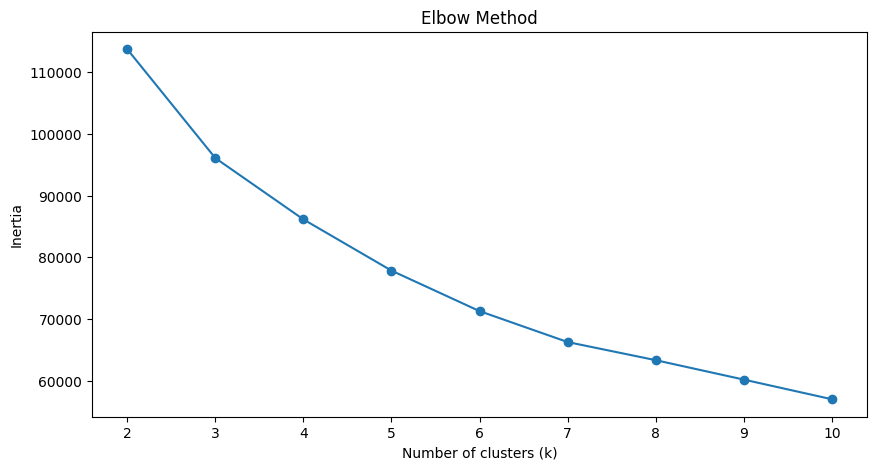

In [389]:
# I test different values of k to understand which number of clusters may be more suitable.
inertia_values = []
k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    inertia_values.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(k_values, inertia_values, marker="o")
plt.title("Elbow Method")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.show()

### Observations on the Results

The Elbow Method chart shows a marked reduction in inertia for the first values of `k`.

Starting from approximately **4-6 clusters**, the curve gradually tends to flatten. This indicates that adding further clusters produces an increasingly limited improvement in the internal compactness of the groups.

The result therefore suggests further evaluating the number of clusters by also comparing other metrics, such as the Silhouette Score.

## Evaluating Cluster Quality with the Silhouette Score

**Objective:** evaluate the quality of separation between clusters for different values of `k`.

In this phase, the Silhouette Score is calculated for each number of clusters ranging from 2 to 10. This metric measures how similar each observation is to its own cluster compared to the other clusters.

The comparison between different values of `k` makes it possible to integrate the indications provided by the Elbow Method with a measure of the quality of separation between groups.

,Number of clusters (k),Silhouette Score
0,2,0.254002
1,3,0.225605
2,4,0.224155
3,5,0.225696
4,6,0.222899
5,7,0.227844
6,8,0.222941
7,9,0.186530
8,10,0.192596


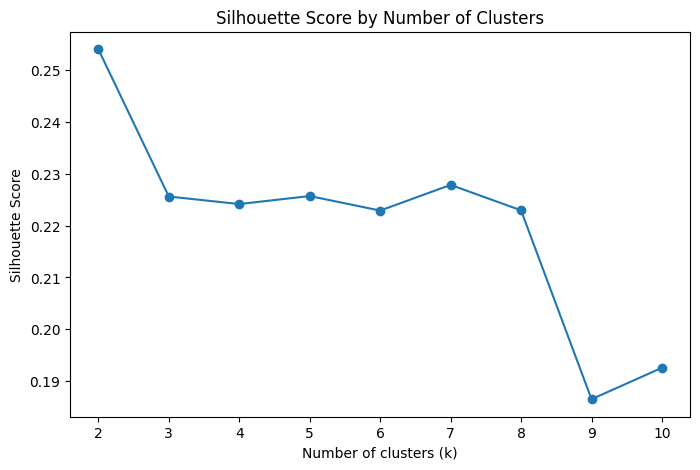

In [390]:
# I calculate the Silhouette Score for each value of k.
# This indicator measures how well the clusters are separated from each other.
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(df_scaled)
    score = silhouette_score(df_scaled, cluster_labels)
    silhouette_scores.append(score)

silhouette_table = pd.DataFrame({
    "Number of clusters (k)": list(k_values),
    "Silhouette Score": silhouette_scores
})

display(silhouette_table)

plt.figure(figsize=(8, 5))
plt.plot(k_values, silhouette_scores, marker="o")
plt.title("Silhouette Score by Number of Clusters")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.show()

### Observations on the Results

The Silhouette Score table and chart show that the highest value is obtained with `k=2`, equal to approximately **0.254**. However, a segmentation composed of only two groups would be excessively aggregated compared to the objective of the project, which is not only to maximize a statistical metric, but also to identify customer profiles that are useful for targeted marketing campaigns.

Looking at the remaining solutions, it can be observed that the Silhouette Score values from `k=3` to `k=8` are relatively close to each other, ranging approximately between **0.223** and **0.228**. In particular, `k=4` has a value of approximately **0.224**, while some solutions with more clusters, such as `k=5` and `k=7`, obtain only slightly higher values. On the other hand, the solutions with `k=9` and `k=10` show a more evident decrease in the Silhouette Score, suggesting a lower quality of separation between clusters.

For this reason, the choice of `k=4` represents a balanced compromise between statistical quality, interpretative simplicity, and managerial usefulness. Compared to `k=2`, it makes it possible to obtain a less generic segmentation that is more suitable for the development of differentiated marketing strategies. At the same time, compared to solutions with a higher number of clusters, it maintains a structure that is easier to interpret and communicate from a business perspective.



## Comparative Evaluation of Clustering Solutions

To strengthen the choice of the final number of clusters, different solutions from `k=2` to `k=6` are compared using multiple validation metrics: Silhouette Score, Calinski-Harabasz Score, and Davies-Bouldin Score.  
In addition, for each value of `k`, the cluster sizes and a brief interpretation of the resulting profiles are analyzed.

In [391]:
# Range of k values to compare
k_values_comparison = range(2, 7)

## Preparing the Dataset for Cluster Profiling

**Objective:** create a dataset in the original scale to interpret the clusters.

Clustering is performed on standardized data, but the interpretation of the groups must be carried out using the original values of the variables, in order to make customer profiles more readable from a business perspective.

For this reason, a support dataset is created by excluding the identifier variable `CUST_ID`. The same logical consistency corrections applied during preprocessing are also applied to this profiling dataset, including the correction of out-of-range frequency values and inconsistent payment or transaction records.

After these corrections, the remaining missing values in `CREDIT_LIMIT`, `MINIMUM_PAYMENTS`, and `PURCHASES_TRX` are imputed using the median of the respective variables. Final consistency adjustments are then applied to ensure that the profiling dataset remains aligned with the preprocessing logic used for clustering.

In [392]:
# Prepare original-scale data for cluster profiling

df_profile_base = df.drop("CUST_ID", axis=1).copy()

tolerance = 0.01

df_profile_base[frequency_cols] = df_profile_base[frequency_cols].clip(0, 1)

df_profile_base.loc[
    df_profile_base["MINIMUM_PAYMENTS"] > df_profile_base["PAYMENTS"],
    "MINIMUM_PAYMENTS"
] = np.nan

df_profile_base.loc[
    (df_profile_base["PURCHASES"] == 0) & (df_profile_base["PURCHASES_TRX"] > 0),
    "PURCHASES_TRX"
] = 0

df_profile_base.loc[
    (df_profile_base["PURCHASES"] > 0) & (df_profile_base["PURCHASES_TRX"] == 0),
    "PURCHASES_TRX"
] = np.nan

df_profile_base.loc[
    (df_profile_base["PURCHASES"] == 0) & (df_profile_base["PURCHASES_FREQUENCY"] > 0),
    "PURCHASES_FREQUENCY"
] = 0

df_profile_base.loc[
    (df_profile_base["INSTALLMENTS_PURCHASES"] == 0)
    & (df_profile_base["PURCHASES_INSTALLMENTS_FREQUENCY"] > 0),
    "PURCHASES_INSTALLMENTS_FREQUENCY"
] = 0

df_profile_base.loc[
    df_profile_base["ONEOFF_PURCHASES"] + df_profile_base["INSTALLMENTS_PURCHASES"]
    > df_profile_base["PURCHASES"] + tolerance,
    "PURCHASES"
] = (
    df_profile_base["ONEOFF_PURCHASES"] + df_profile_base["INSTALLMENTS_PURCHASES"]
)

df_profile_base["CREDIT_LIMIT"] = df_profile_base["CREDIT_LIMIT"].fillna(
    df_profile_base["CREDIT_LIMIT"].median()
)

df_profile_base["MINIMUM_PAYMENTS"] = df_profile_base["MINIMUM_PAYMENTS"].fillna(
    df_profile_base["MINIMUM_PAYMENTS"].median()
)

df_profile_base["PURCHASES_TRX"] = df_profile_base["PURCHASES_TRX"].fillna(
    df_profile_base["PURCHASES_TRX"].median()
)

df_profile_base["MINIMUM_PAYMENTS"] = df_profile_base[
    ["MINIMUM_PAYMENTS", "PAYMENTS"]
].min(axis=1)

df_profile_base.loc[
    (df_profile_base["PURCHASES"] > 0) & (df_profile_base["PURCHASES_TRX"] == 0),
    "PURCHASES_TRX"
] = 1



## Variables Used for Cluster Interpretation

**Objective:** select the main variables to describe customer profiles.

In this phase, the variables used to interpret the clusters obtained with K-Means are defined.  
The selection includes indicators related to balance, purchases, cash advances, payments, usage frequency, and credit limit.

A dictionary of descriptive labels is also created, which is useful for making the automatic summary of the profiles more readable.

In [393]:
# Main variables used to interpret the clusters
profile_variables = [
    "BALANCE",
    "PURCHASES",
    "ONEOFF_PURCHASES",
    "INSTALLMENTS_PURCHASES",
    "CASH_ADVANCE",
    "PURCHASES_FREQUENCY",
    "PURCHASES_TRX",
    "PAYMENTS",
    "MINIMUM_PAYMENTS",
    "PRC_FULL_PAYMENT",
    "CREDIT_LIMIT"
]

feature_labels = {
    "BALANCE": "balance",
    "PURCHASES": "purchases",
    "ONEOFF_PURCHASES": "one-off purchases",
    "INSTALLMENTS_PURCHASES": "installment purchases",
    "CASH_ADVANCE": "cash advance",
    "PURCHASES_FREQUENCY": "purchase frequency",
    "PURCHASES_TRX": "number of purchase transactions",
    "PAYMENTS": "payments",
    "MINIMUM_PAYMENTS": "minimum payments",
    "PRC_FULL_PAYMENT": "full payment percentage",
    "CREDIT_LIMIT": "credit limit"
}

## Function for the Synthetic Description of Clusters

**Objective:** generate a brief automatic description of the profiles that emerged.

The function compares the averages of each cluster with the overall average of the dataset.  
In this way, it is possible to identify, for each group, the variables that take relatively higher or lower values compared to the overall customer base.

This description does not replace the final interpretation of the clusters, but it represents a support for synthetically comparing the different clustering solutions.

In [394]:
def describe_clusters(profile_means):
    """
    Create a short automatic description of each cluster.

    The function compares the average values of each cluster
    with the overall average of the dataset.
    """
    overall_mean = df_profile_base[profile_variables].mean()
    overall_std = df_profile_base[profile_variables].std().replace(0, np.nan)

    profile_z = (profile_means[profile_variables] - overall_mean) / overall_std

    descriptions = []

    for cluster_id, row in profile_z.iterrows():
        top_features = row.sort_values(ascending=False).head(2)
        low_feature = row.sort_values(ascending=True).head(1)

        high_labels = [
            feature_labels.get(feature, feature)
            for feature, value in top_features.items()
            if value > 0.35
        ]

        if high_labels:
            description = f"C{cluster_id}: high values in " + ", ".join(high_labels)
        else:
            description = f"C{cluster_id}: profile close to the average"

        if low_feature.iloc[0] < -0.35:
            low_label = feature_labels.get(low_feature.index[0], low_feature.index[0])
            description += f", low values in {low_label}"

        descriptions.append(description)

    return " | ".join(descriptions)

## Calculating Metrics for Different Values of k

**Objective:** evaluate the performance of the different clustering solutions.

For each value of `k`, a K-Means model is trained on the standardized data.  
Subsequently, the main validation metrics are calculated and the distribution of customers across clusters is analyzed.

The information obtained is collected in a list of results, which will then be transformed into a comparative table.

In [395]:
comparison_results = []

# Try K-Means with different values of k and save the results.
for k in k_values_comparison:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(df_scaled)

    # Calculate how many customers are in each cluster and their percentage.
    cluster_sizes = pd.Series(labels).value_counts().sort_index()
    cluster_percentages = (cluster_sizes / len(df_scaled) * 100).round(2)

    temp_profile = df_profile_base.copy()
    temp_profile["Cluster"] = labels

    profile_means = temp_profile.groupby("Cluster")[profile_variables].mean()

    # Save the metrics and a short description to compare the different solutions.
    comparison_results.append({
        "k": k,
        "Silhouette Score": silhouette_score(df_scaled, labels),
        "Calinski-Harabasz Score": calinski_harabasz_score(df_scaled, labels),
        "Davies-Bouldin Score": davies_bouldin_score(df_scaled, labels),
        "Cluster sizes": ", ".join(
            [f"C{i}: {cluster_sizes[i]} ({cluster_percentages[i]}%)" for i in cluster_sizes.index]
        ),
        "Smallest cluster (%)": cluster_percentages.min(),
        "Largest cluster (%)": cluster_percentages.max(),
        "Synthetic interpretability": describe_clusters(profile_means)
    })

## Technical Comparison Table

**Objective:** display the metrics obtained for each value of `k` in tabular form.

The table makes it possible to compare the different solutions based on statistical metrics and the percentage distribution of the clusters.

This analysis helps assess whether increasing the number of clusters actually improves the quality of the segmentation or only introduces greater fragmentation.

In [396]:
comparison_table = pd.DataFrame(comparison_results)

comparison_table = comparison_table.round({
    "Silhouette Score": 4,
    "Calinski-Harabasz Score": 2,
    "Davies-Bouldin Score": 4,
    "Smallest cluster (%)": 2,
    "Largest cluster (%)": 2
})

pd.set_option("display.max_colwidth", None)

# Technical table with the main clustering metrics.
display(comparison_table.drop(columns=["Synthetic interpretability"]))

,k,Silhouette Score,Calinski-Harabasz Score,Davies-Bouldin Score,Cluster sizes,Smallest cluster (%),Largest cluster (%)
0,2,0.2540,3020.29,1.4979,"C0: 5819 (65.02%), C1: 3131 (34.98%)",34.98,65.02
1,3,0.2256,2608.94,1.6925,"C0: 3102 (34.66%), C1: 2835 (31.68%), C2: 3013 (33.66%)",31.68,34.66
2,4,0.2242,2283.99,1.6743,"C0: 1510 (16.87%), C1: 2551 (28.5%), C2: 2727 (30.47%), C3: 2162 (24.16%)",16.87,30.47
3,5,0.2257,2134.19,1.5698,"C0: 1186 (13.25%), C1: 1347 (15.05%), C2: 2503 (27.97%), C3: 1999 (22.34%), C4: 1915 (21.4%)",13.25,27.97
4,6,0.2229,2029.30,1.4389,"C0: 1442 (16.11%), C1: 1390 (15.53%), C2: 1244 (13.9%), C3: 1780 (19.89%), C4: 2214 (24.74%), C5: 880 (9.83%)",9.83,24.74


## Managerial Evaluation of the Solutions

**Objective:** integrate statistical metrics with an operational evaluation.

Since the project has marketing purposes, the choice of the number of clusters cannot be based exclusively on statistical metrics.  
It is also necessary to consider the readability of the segments, their size, and the possibility of translating them into targeted campaigns.

For this reason, a summary table is created to compare the different solutions from a managerial perspective and identify the final choice.

In [397]:
# Summary table to justify the final choice
business_evaluation = comparison_table[[
    "k",
    "Smallest cluster (%)",
    "Largest cluster (%)"
]].copy()

business_evaluation["Managerial evaluation"] = [
    "Too aggregated: only two groups, not very suitable for differentiated campaigns.",
    "Balanced, but still not detailed enough in terms of usage behavior.",
    "Best compromise: four readable, well-distributed, and actionable segments.",
    "Possible, but it introduces greater fragmentation without a clear advantage.",
    "More fragmented and less immediate to interpret from a managerial perspective."
]

business_evaluation["Decision"] = [
    "Not selected",
    "Not selected",
    "Final choice",
    "Not selected",
    "Not selected"
]

display(business_evaluation)

,k,Smallest cluster (%),Largest cluster (%),Managerial evaluation,Decision
0,2,34.98,65.02,"Too aggregated: only two groups, not very suitable for differentiated campaigns.",Not selected
1,3,31.68,34.66,"Balanced, but still not detailed enough in terms of usage behavior.",Not selected
2,4,16.87,30.47,"Best compromise: four readable, well-distributed, and actionable segments.",Final choice
3,5,13.25,27.97,"Possible, but it introduces greater fragmentation without a clear advantage.",Not selected
4,6,9.83,24.74,More fragmented and less immediate to interpret from a managerial perspective.,Not selected


### Observations on the Results

The comparison shows that `k=2` achieves the highest Silhouette Score, equal to `0.2540`, as well as the highest Calinski-Harabasz Score, equal to `3020.29`. However, this solution produces a highly aggregated segmentation, with only two groups and a dominant cluster containing `65.02%` of customers. For this reason, it is not very suitable for building truly differentiated marketing campaigns.

The solution with `k=3` maintains very balanced clusters, with percentages ranging from `31.68%` to `34.66%`, but shows a decrease in the Silhouette Score to `0.2256` and still does not allow for a sufficiently detailed distinction of credit card usage behaviors.

The solution with `k=4` has a Silhouette Score equal to `0.2242`, lower than `k=2` and slightly lower than `k=3`, but maintains a balanced customer distribution: the smallest cluster represents `16.87%` of the dataset and the largest one represents `30.47%`. This configuration makes it possible to distinguish four clear profiles that are consistent with the objectives of the project.

The solutions with `k=5` and `k=6` show Silhouette values close to `k=4`, respectively `0.2257` and `0.2229`, but introduce greater segmentation fragmentation. In particular, with `k=6`, the smallest cluster drops to `9.83%`, making the segmentation more complex to interpret and less immediate to use from a managerial perspective.

Overall, the final choice of `k=4` does not result from superiority across all statistical metrics, but from a compromise between clustering quality, customer distribution, interpretative clarity, and operational usefulness. For a targeted marketing project, four clusters represent a more actionable solution than segmentations that are either too aggregated or excessively fragmented.


## Final Verification of the Choice of k = 4

**Objective:** confirm the choice of the final number of clusters through an operational comparison with the closest alternative solution.

In this phase, the solutions with `k=4` and `k=5` are compared, both obtained through K-Means on the standardized data. For both solutions, the cluster sizes are calculated in order to verify whether very small or poorly balanced groups emerge.

This comparison integrates the previous analyses and helps strengthen the choice of `k=4`, which is easier to interpret and more suitable for building targeted marketing campaigns.

In [398]:
kmeans_4 = KMeans(n_clusters=4, random_state=42, n_init=10)
labels_4 = kmeans_4.fit_predict(df_scaled)

kmeans_5 = KMeans(n_clusters=5, random_state=42, n_init=10)
labels_5 = kmeans_5.fit_predict(df_scaled)

cluster_sizes_4 = pd.Series(labels_4).value_counts().sort_index()
cluster_sizes_5 = pd.Series(labels_5).value_counts().sort_index()

print("Cluster sizes for k=4:")
print(cluster_sizes_4)

print("\nCluster sizes for k=5:")
print(cluster_sizes_5)

Cluster sizes for k=4:
0    1510
1    2551
2    2727
3    2162
Name: count, dtype: int64

Cluster sizes for k=5:
0    1186
1    1347
2    2503
3    1999
4    1915
Name: count, dtype: int64


### Observations on the results

The comparison between `k=4` and `k=5` shows that, in both cases, the clusters have fairly balanced sizes and no excessively small groups emerge.

However, the solution with `k=4` appears easier to interpret, while still maintaining a good distribution of observations across the groups. The solution with `k=5`, although possible, introduces an additional cluster that could make the segmentation less straightforward from a managerial perspective.

Considering the results of the Elbow Method, the Silhouette Score, and the cluster distribution together, `k=4` represents the most solid candidate for the final segmentation.

## Creation of the final model with k = 4

**Objective:** apply the final K-Means model using the selected number of clusters.

In this phase, the K-Means model is trained with `k=4` on the standardized data. The cluster labels are then assigned to the original cleaned dataset, so that the groups can be interpreted in terms of real, non-standardized values.

This choice makes it possible to combine the technical correctness of the model, based on the preprocessed data, with a clearer interpretation of the customer profiles.

In [399]:
# Train the final K-Means model with 4 clusters.
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
final_labels = kmeans_final.fit_predict(df_scaled)

# Create a cleaned copy of the original dataset for cluster interpretation.
df_clustered = df.copy()

tolerance = 0.01

frequency_cols = [
    "BALANCE_FREQUENCY",
    "PURCHASES_FREQUENCY",
    "ONEOFF_PURCHASES_FREQUENCY",
    "PURCHASES_INSTALLMENTS_FREQUENCY",
    "CASH_ADVANCE_FREQUENCY",
    "PRC_FULL_PAYMENT"
]

df_clustered[frequency_cols] = df_clustered[frequency_cols].clip(0, 1)

df_clustered.loc[
    df_clustered["MINIMUM_PAYMENTS"] > df_clustered["PAYMENTS"],
    "MINIMUM_PAYMENTS"
] = np.nan

df_clustered.loc[
    (df_clustered["PURCHASES"] == 0) & (df_clustered["PURCHASES_TRX"] > 0),
    "PURCHASES_TRX"
] = 0

df_clustered.loc[
    (df_clustered["PURCHASES"] > 0) & (df_clustered["PURCHASES_TRX"] == 0),
    "PURCHASES_TRX"
] = np.nan

df_clustered.loc[
    (df_clustered["PURCHASES"] == 0) & (df_clustered["PURCHASES_FREQUENCY"] > 0),
    "PURCHASES_FREQUENCY"
] = 0

df_clustered.loc[
    (df_clustered["INSTALLMENTS_PURCHASES"] == 0)
    & (df_clustered["PURCHASES_INSTALLMENTS_FREQUENCY"] > 0),
    "PURCHASES_INSTALLMENTS_FREQUENCY"
] = 0

df_clustered.loc[
    df_clustered["ONEOFF_PURCHASES"] + df_clustered["INSTALLMENTS_PURCHASES"]
    > df_clustered["PURCHASES"] + tolerance,
    "PURCHASES"
] = (
    df_clustered["ONEOFF_PURCHASES"] + df_clustered["INSTALLMENTS_PURCHASES"]
)

df_clustered["CREDIT_LIMIT"] = df_clustered["CREDIT_LIMIT"].fillna(df_clustered["CREDIT_LIMIT"].median())
df_clustered["MINIMUM_PAYMENTS"] = df_clustered["MINIMUM_PAYMENTS"].fillna(df_clustered["MINIMUM_PAYMENTS"].median())
df_clustered["PURCHASES_TRX"] = df_clustered["PURCHASES_TRX"].fillna(df_clustered["PURCHASES_TRX"].median())

df_clustered["MINIMUM_PAYMENTS"] = df_clustered[["MINIMUM_PAYMENTS", "PAYMENTS"]].min(axis=1)

df_clustered.loc[
    (df_clustered["PURCHASES"] > 0) & (df_clustered["PURCHASES_TRX"] == 0),
    "PURCHASES_TRX"
] = 1

df_clustered["Cluster"] = final_labels

display(df_clustered[[
    "CUST_ID",
    "BALANCE",
    "PURCHASES",
    "CASH_ADVANCE",
    "CREDIT_LIMIT",
    "PAYMENTS",
    "MINIMUM_PAYMENTS",
    "PRC_FULL_PAYMENT",
    "TENURE",
    "Cluster"
]].head())


,CUST_ID,BALANCE,PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,Cluster
0,C10001,40.900749,95.40,0.000000,1000.0,201.802084,139.509787,0.000000,12,0
1,C10002,3202.467416,0.00,6442.945483,7000.0,4103.032597,1072.340217,0.222222,12,2
2,C10003,2495.148862,773.17,0.000000,7500.0,622.066742,214.237153,0.000000,12,1
3,C10004,1666.670542,1499.00,205.788017,7500.0,0.000000,0.000000,0.000000,12,0
4,C10005,817.714335,16.00,0.000000,1200.0,678.334763,244.791237,0.000000,12,0


### Observations on the results

The final K-Means model with `k=4` was trained on the standardized data and assigned each customer to one of the four identified clusters.

The cluster labels were added to the `df_clustered` DataFrame, which keeps the cleaned original variables. This makes it possible to analyze the segments using interpretable values, such as spending amounts, balance, payments, usage frequencies, and credit limit.

The dataset preview confirms the presence of the new `Cluster` column, which will be used in the next phases of segment analysis and interpretation.

## Clustering stability check

**Objective:** check whether the final solution with `k=4` remains stable when varying the `random_state`.

Since K-Means can produce slightly different results depending on the initial centroid initialization, the model is run multiple times with different `random_state` values.

Stability is evaluated by comparing the silhouette score, inertia, cluster sizes, and the similarity between assignments using the Adjusted Rand Index.

In [400]:
# Try different random_state values to check whether the model produces similar results.
# If the results change only slightly, the clustering is more stable.
random_states = [0, 1, 7, 21, 42, 99, 123, 2024]

stability_results = []
labels_by_seed = {}

for seed in random_states:
    kmeans = KMeans(n_clusters=4, random_state=seed, n_init=10)
    labels = kmeans.fit_predict(df_scaled)

    labels_by_seed[seed] = labels

    cluster_sizes = pd.Series(labels).value_counts().sort_index()
    cluster_percentages = (cluster_sizes / len(df_scaled) * 100).round(2)

    stability_results.append({
        "random_state": seed,
        "inertia": kmeans.inertia_,
        "silhouette_score": silhouette_score(df_scaled, labels),
        "cluster_sizes": "; ".join([f"C{i}: {cluster_sizes[i]}" for i in cluster_sizes.index]),
        "cluster_percentages": "; ".join([f"C{i}: {cluster_percentages[i]}%" for i in cluster_percentages.index])
    })

stability_table = pd.DataFrame(stability_results)

stability_table.round({
    "inertia": 2,
    "silhouette_score": 4
})

,random_state,inertia,silhouette_score,cluster_sizes,cluster_percentages
0,0,86159.12,0.2242,C0: 1510; C1: 2158; C2: 2557; C3: 2725,C0: 16.87%; C1: 24.11%; C2: 28.57%; C3: 30.45%
1,1,86158.75,0.2242,C0: 2159; C1: 2726; C2: 2556; C3: 1509,C0: 24.12%; C1: 30.46%; C2: 28.56%; C3: 16.86%
2,7,86158.72,0.2242,C0: 1509; C1: 2725; C2: 2551; C3: 2165,C0: 16.86%; C1: 30.45%; C2: 28.5%; C3: 24.19%
3,21,86158.78,0.2242,C0: 2158; C1: 2724; C2: 1509; C3: 2559,C0: 24.11%; C1: 30.44%; C2: 16.86%; C3: 28.59%
4,42,86158.74,0.2242,C0: 1510; C1: 2551; C2: 2727; C3: 2162,C0: 16.87%; C1: 28.5%; C2: 30.47%; C3: 24.16%
5,99,86158.75,0.2242,C0: 2726; C1: 2159; C2: 1509; C3: 2556,C0: 30.46%; C1: 24.12%; C2: 16.86%; C3: 28.56%
6,123,86158.75,0.2241,C0: 2158; C1: 2727; C2: 1510; C3: 2555,C0: 24.11%; C1: 30.47%; C2: 16.87%; C3: 28.55%
7,2024,86158.75,0.2239,C0: 2728; C1: 1518; C2: 2149; C3: 2555,C0: 30.48%; C1: 16.96%; C2: 24.01%; C3: 28.55%


In [401]:
# The Adjusted Rand Index compares two cluster assignments.
# A value close to 1 indicates that the results are very similar.
ari_results = []

reference_seed = 42
reference_labels = labels_by_seed[reference_seed]

for seed in random_states:
    ari = adjusted_rand_score(reference_labels, labels_by_seed[seed])

    ari_results.append({
        "reference_random_state": reference_seed,
        "compared_random_state": seed,
        "adjusted_rand_index": ari
    })

ari_table = pd.DataFrame(ari_results)

ari_table.round(4)

,reference_random_state,compared_random_state,adjusted_rand_index
0,42,0,0.9971
1,42,1,0.9982
2,42,7,0.9985
3,42,21,0.9972
4,42,42,1.0000
5,42,99,0.9982
6,42,123,0.9988
7,42,2024,0.9917


### Observations on the results

The stability check shows that the solution with `k=4` is overall robust with respect to the choice of `random_state`.

The inertia values are very similar across all executions, while the Silhouette Score remains almost unchanged, with values approximately equal to `0.2241`. This indicates that the overall quality of the clustering does not depend significantly on the random initialization of the centroids.

The Adjusted Rand Index also confirms strong stability of the segmentation. The values are always very high and close to `1`, with a minimum value of approximately `0.9917`. This means that customer assignments to clusters remain very similar compared to the reference solution with `random_state=42`.

The observed differences in cluster names, such as `C0`, `C1`, `C2`, and `C3`, should not be interpreted as substantial changes in the segments, because numerical cluster labels are arbitrary and may change order from one execution to another.

Overall, these results strengthen the choice of using `k=4`, since the segmentation is stable, interpretable, and consistent with the objective of identifying customer groups useful for targeted marketing campaigns.



## Cluster visualization using PCA

**Objective:** graphically represent the clusters in a two-dimensional space.

After applying the K-Means model, PCA is used to reduce the dimensionality of the standardized dataset to two principal components.

This visualization makes it possible to observe the distribution of customers across the different clusters and to visually assess whether the identified groups show a recognizable separation.

,Principal component,Explained variance,Explained variance (%)
0,PC1,0.336421,33.642095
1,PC2,0.222561,22.256065


Total variance explained by the first two components: 55.90%


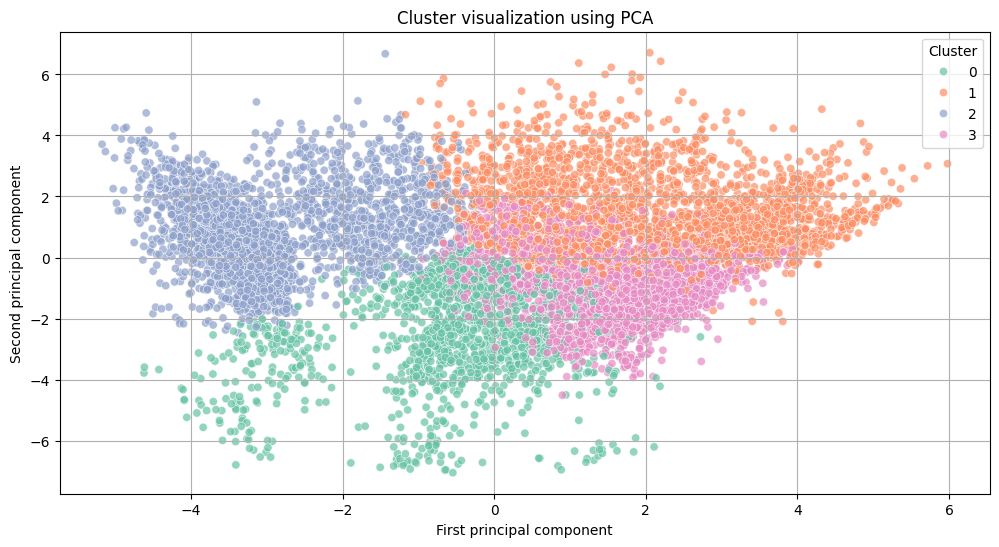

In [402]:
# I use PCA only to visualize the clusters in two dimensions.
# The final model was instead built using all the standardized variables.
pca = PCA(n_components=2)
pca_components = pca.fit_transform(df_scaled)

# Percentage of variance explained by the two principal components
explained_variance = pca.explained_variance_ratio_
total_explained_variance = explained_variance.sum()

variance_table = pd.DataFrame({
    "Principal component": ["PC1", "PC2"],
    "Explained variance": explained_variance,
    "Explained variance (%)": explained_variance * 100
})

display(variance_table)

print(f"Total variance explained by the first two components: {total_explained_variance:.2%}")

# Create a DataFrame to visualize the clusters in 2 dimensions
pca_df = pd.DataFrame(
    data=pca_components,
    columns=["PC1", "PC2"]
)

pca_df["Cluster"] = final_labels

# Cluster visualization using PCA
plt.figure(figsize=(12, 6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="Set2",
    alpha=0.7
)

plt.title("Cluster visualization using PCA")
plt.xlabel("First principal component")
plt.ylabel("Second principal component")
plt.legend(title="Cluster")
plt.grid(True)
plt.show()

### Observations on the results

The PCA visualization represents the clusters identified by the K-Means model in a two-dimensional space, reducing the complexity of the original dataset.

The first two principal components explain approximately **55.90%** of the total variance of the dataset: the first component explains about **33.64%**, while the second explains about **22.26%**. This means that the two-dimensional chart summarizes a relevant part of the information contained in the data, although it does not represent the full complexity of the original dataset.

The chart shows that the clusters are not perfectly separated and present some overlapping areas. This result is consistent with the moderate Silhouette Score, which indicates that the separation between the groups is not completely clear-cut.

However, the segmentation remains useful from an interpretative and business perspective, as it makes it possible to distinguish customer profiles with different behaviors in the use of credit cards.


## Analysis of average variable values by cluster

**Objective:** interpret the clusters through the average value of the main variables.

In this phase, the average of the numerical variables is calculated for each cluster. This makes it possible to compare the groups identified by the model and describe the different customer profiles based on balance, purchases, cash advances, payments, and card usage frequency.

In [403]:
cluster_profile = df_clustered.groupby("Cluster").mean(numeric_only=True).round(2)
cluster_profile

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
Cluster,,,,,,,,,,,,,,,,,
0,295.73,0.55,343.23,281.19,62.04,151.81,0.23,0.12,0.11,0.02,0.45,3.60,3533.63,699.53,118.17,0.14,11.29
1,2185.66,0.98,2625.24,1776.12,849.12,854.50,0.82,0.56,0.54,0.11,2.83,35.56,6408.76,2957.33,577.60,0.18,11.81
2,2459.46,0.94,100.98,78.00,22.98,2231.09,0.07,0.04,0.03,0.31,7.43,1.20,4378.65,1845.38,472.11,0.03,11.39
3,588.78,0.91,689.51,62.04,627.48,123.79,0.80,0.04,0.76,0.02,0.43,14.92,3052.14,869.04,238.91,0.28,11.48


## Selection of the main variables for cluster interpretation

**Objective:** focus on the most relevant variables to describe customer profiles.

In this phase, some key variables related to balance, purchases, cash advance, payments, and credit limit are selected. This makes the comparison between clusters easier to read and facilitates the subsequent interpretation of the segments.

In [404]:
key_variables = [
    "BALANCE",
    "PURCHASES",
    "ONEOFF_PURCHASES",
    "INSTALLMENTS_PURCHASES",
    "CASH_ADVANCE",
    "PURCHASES_FREQUENCY",
    "PURCHASES_TRX",
    "PAYMENTS",
    "MINIMUM_PAYMENTS",
    "PRC_FULL_PAYMENT",
    "CREDIT_LIMIT"
]

cluster_profile_key = df_clustered.groupby("Cluster")[key_variables].mean().round(2)
cluster_profile_key

,BALANCE,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,PURCHASES_TRX,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,CREDIT_LIMIT
Cluster,,,,,,,,,,,
0,295.73,343.23,281.19,62.04,151.81,0.23,3.60,699.53,118.17,0.14,3533.63
1,2185.66,2625.24,1776.12,849.12,854.50,0.82,35.56,2957.33,577.60,0.18,6408.76
2,2459.46,100.98,78.00,22.98,2231.09,0.07,1.20,1845.38,472.11,0.03,4378.65
3,588.78,689.51,62.04,627.48,123.79,0.80,14.92,869.04,238.91,0.28,3052.14


### Observations on the results

The analysis of the average values by cluster highlights relevant differences in credit card usage behavior.

`Cluster 0` includes customers with a low overall level of activity: a limited average balance, few purchases, a reduced number of transactions, and limited use of cash advance.

`Cluster 1` shows the highest average values for total purchases, one-off purchases, number of purchase transactions, credit limit, and payments. This group therefore represents the most active customer segment, with greater spending capacity and intensive card usage.

`Cluster 2` stands out for its strong use of cash advance: it shows high average values for cash advance amount, cash advance frequency, and related transaction count, while purchases are more limited.

`Cluster 3` is characterized by a prevalence of installment purchases, together with a high card usage frequency and a higher share of full payment compared to other groups.


## Robust cluster profiling

**Objective:** strengthen the interpretation of the clusters through more robust statistics than the mean alone.

In this phase, in addition to the mean, the median, first quartile, third quartile, minimum values, maximum values, and percentage of zero values are also calculated for each cluster. This makes it possible to better analyze the distribution of the variables and reduce the risk of interpretations based only on average values influenced by outliers or highly skewed distributions.

In [405]:
robust_profile_variables = [
    "BALANCE",
    "PURCHASES",
    "ONEOFF_PURCHASES",
    "INSTALLMENTS_PURCHASES",
    "CASH_ADVANCE",
    "PURCHASES_FREQUENCY",
    "PURCHASES_TRX",
    "PAYMENTS",
    "MINIMUM_PAYMENTS",
    "PRC_FULL_PAYMENT",
    "CREDIT_LIMIT"
]

robust_profile = (
    df_clustered
    .groupby("Cluster")[robust_profile_variables]
    .agg(["mean", "median", "min", "max"])
    .round(2)
)

q1_profile = (
    df_clustered
    .groupby("Cluster")[robust_profile_variables]
    .quantile(0.25)
    .round(2)
)

q3_profile = (
    df_clustered
    .groupby("Cluster")[robust_profile_variables]
    .quantile(0.75)
    .round(2)
)

zero_profile = (
    df_clustered
    .groupby("Cluster")[robust_profile_variables]
    .apply(lambda x: (x.eq(0).mean() * 100).round(2))
)

robust_summary = []

for cluster in sorted(df_clustered["Cluster"].unique()):
    for variable in robust_profile_variables:
        robust_summary.append({
            "Cluster": cluster,
            "Variable": variable,
            "Mean": robust_profile.loc[cluster, (variable, "mean")],
            "Median": robust_profile.loc[cluster, (variable, "median")],
            "Q1": q1_profile.loc[cluster, variable],
            "Q3": q3_profile.loc[cluster, variable],
            "Min": robust_profile.loc[cluster, (variable, "min")],
            "Max": robust_profile.loc[cluster, (variable, "max")],
            "% zero values": zero_profile.loc[cluster, variable]
        })

robust_summary = pd.DataFrame(robust_summary)

robust_summary

,Cluster,Variable,Mean,Median,Q1,Q3,Min,Max,% zero values
0,0,BALANCE,295.73,44.27,9.07,241.93,0.00,7024.27,4.83
1,0,PURCHASES,343.23,161.38,60.00,438.40,0.00,3950.00,11.19
2,0,ONEOFF_PURCHASES,281.19,74.00,0.00,359.75,0.00,3950.00,37.95
3,0,INSTALLMENTS_PURCHASES,62.04,0.00,0.00,74.47,0.00,1151.45,63.38
4,0,CASH_ADVANCE,151.81,0.00,0.00,0.00,0.00,7616.06,81.19
5,0,PURCHASES_FREQUENCY,0.23,0.17,0.08,0.33,0.00,1.00,11.19
6,0,PURCHASES_TRX,3.60,2.00,1.00,5.00,0.00,36.00,11.19
7,0,PAYMENTS,699.53,300.33,109.27,682.45,0.00,29272.49,14.30
8,0,MINIMUM_PAYMENTS,118.17,101.53,42.17,173.26,0.00,1987.49,14.30
9,0,PRC_FULL_PAYMENT,0.14,0.00,0.00,0.11,0.00,1.00,70.86


In [406]:
robust_summary_pivot = robust_summary.pivot(
    index="Variable",
    columns="Cluster",
    values=["Mean", "Median", "Q1", "Q3", "% zero values"]
)

robust_summary_pivot.round(2)


Mean                              Median                                  Q1                                  Q3                            % zero values                \
Cluster                       0        1        2        3        0        1        2        3        0        1        2        3        0        1        2        3             0      1      2   
Variable                                                                                                                                                                                             
BALANCE                  295.73  2185.66  2459.46   588.78    44.27  1328.48  1695.84   146.92     9.07   468.16   986.37    45.02   241.93  3007.13  3212.18   896.01          4.83   0.00   0.00   
CASH_ADVANCE             151.81   854.50  2231.09   123.79     0.00     0.00  1408.58     0.00     0.00     0.00   463.78     0.00     0.00   836.58  2958.12     0.00         81.19  59.35   0.81   
CREDIT_LIMIT            3533.63  6408.76  4378.65  3052.14  2500.00  6000.00  3000.00  2000.00  1500.00  3000.00  1700.00  1200.00  5000.00  8500.00  6000.00  4000.00          0.00   0.00   0.00   
INSTALLMENTS_PURCHASES    62.04   849.12    22.98   627.48     0.00   432.56     0.00   419.94     0.00    86.62     0.00   240.80    74.47  1088.91     0.00   749.72         63.38  20.07  89.73   
MINIMUM_PAYMENTS         118.17   577.60   472.11   238.91   101.53   236.62   214.24   174.36    42.17   199.68   214.24   135.77   173.26   629.30   505.74   214.24         14.30   0.20   0.33   
ONEOFF_PURCHASES         281.19  1776.12    78.00    62.04    74.00  1049.30     0.00     0.00     0.00   517.30     0.00     0.00   359.75  2062.39     0.00     0.00         37.95   1.96  75.10   
PAYMENTS                 699.53  2957.33  1845.38   869.04   300.33  1847.90   903.97   575.32   109.27   995.71   446.17   308.72   682.45  3477.17  1963.14  1094.63         14.30   0.20   0.33   
PRC_FULL_PAYMENT           0.14     0.18     0.03     0.28     0.00     0.00     0.00     0.08     0.00     0.00     0.00     0.00     0.11     0.18     0.00     0.55         70.86  61.82  81.85   
PURCHASES                343.23  2625.24   100.98   689.51   161.38  1697.02     0.00   469.76    60.00   929.27     0.00   266.69   438.40  3093.36    70.00   833.34         11.19   0.00  68.68   
PURCHASES_FREQUENCY        0.23     0.82     0.07     0.80     0.17     0.92     0.00     0.92     0.08     0.67     0.00     0.67     0.33     1.00     0.08     1.00         11.19   0.00  68.76   
PURCHASES_TRX              3.60    35.56     1.20    14.92     2.00    25.00     0.00    12.00     1.00    13.00     0.00     8.00     5.00    44.00     1.00    17.00         11.19   0.00  68.68   

                               
Cluster                     3  
Variable                       
BALANCE                  0.32  
CASH_ADVANCE            86.31  
CREDIT_LIMIT             0.00  
INSTALLMENTS_PURCHASES   0.00  
MINIMUM_PAYMENTS         0.46  
ONEOFF_PURCHASES        75.44  
PAYMENTS                 0.46  
PRC_FULL_PAYMENT        47.36  
PURCHASES                0.00  
PURCHASES_FREQUENCY      0.00  
PURCHASES_TRX            0.00

### Observations on the results

The robust profiling confirms that cluster interpretation should not be based only on mean values, because many variables show skewed distributions, extreme values, and a strong presence of zeros.

`Cluster 0` confirms the profile of low-activity customers. Average purchases are equal to `343.23`, but the median is lower, equal to `161.38`. In addition, `81.19%` of customers in the cluster do not use cash advance and `70.86%` do not make full payments. These results reinforce the idea of a segment with limited card usage.

`Cluster 1` presents the most intensive usage profile. Average purchases are equal to `2625.24`, with a median of `1697.02`, while the median number of transactions is equal to `25`. Payments are also high, with an average of `2957.33` and a median of `1847.90`. The median credit limit is equal to `6000.00`, higher than in the other clusters.

`Cluster 2` stands out for its strong use of cash advance. The average cash advance amount is equal to `2231.09` and the median is equal to `1408.58`, while only `0.81%` of customers have a zero value for this variable. By contrast, `68.68%` of customers do not make purchases and `81.85%` do not make full payments. This confirms a segment mainly oriented toward cash advances.

`Cluster 3` shows behavior more oriented toward installment purchases. The median value of installment purchases is equal to `419.94` and the median purchase frequency is equal to `0.92`, confirming regular card usage. The percentage of zero values for installment purchases is equal to `0.00%`, indicating that this feature is widespread within the cluster.

Overall, the analysis through mean, median, quartiles, and percentage of zeros makes the interpretation of the segments more robust, because it shows that the differences between clusters do not depend only on mean values influenced by outliers.



## Assignment of descriptive labels to the clusters

**Objective:** make the clusters identified by the model easier to interpret.

In this phase, each numerical cluster is associated with a descriptive label, built on the basis of the average characteristics observed in the group profiles. This makes the segmentation more understandable also from a managerial and marketing perspective.

In [407]:
cluster_names = {
    0: "Low-activity customers",
    1: "High-spending and high-activity customers",
    2: "High cash advance usage customers",
    3: "Installment purchase-oriented customers"
}

df_clustered["Cluster_Name"] = df_clustered["Cluster"].map(cluster_names)

df_clustered[["Cluster", "Cluster_Name"]].head()


,Cluster,Cluster_Name
0,0,Low-activity customers
1,2,High cash advance usage customers
2,1,High-spending and high-activity customers
3,0,Low-activity customers
4,0,Low-activity customers


In [408]:
cluster_profile_named = cluster_profile_key.copy()
cluster_profile_named.index = cluster_profile_named.index.map(cluster_names)

cluster_profile_named

,BALANCE,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,PURCHASES_TRX,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,CREDIT_LIMIT
Cluster,,,,,,,,,,,
Low-activity customers,295.73,343.23,281.19,62.04,151.81,0.23,3.60,699.53,118.17,0.14,3533.63
High-spending and high-activity customers,2185.66,2625.24,1776.12,849.12,854.50,0.82,35.56,2957.33,577.60,0.18,6408.76
High cash advance usage customers,2459.46,100.98,78.00,22.98,2231.09,0.07,1.20,1845.38,472.11,0.03,4378.65
Installment purchase-oriented customers,588.78,689.51,62.04,627.48,123.79,0.80,14.92,869.04,238.91,0.28,3052.14


### Observations on the results

The assignment of descriptive labels makes it possible to transform numerical clusters into customer segments that are easier to interpret.

The four identified groups are:

- `Cluster 0`: `Low-activity customers`
- `Cluster 1`: `High-spending and high-activity customers`
- `Cluster 2`: `High cash advance usage customers`
- `Cluster 3`: `Installment purchase-oriented customers`

This classification will be used in the following phases to formulate targeted marketing strategies for each segment.


## Percentage distribution of the clusters

**Objective:** evaluate the relative size of the identified segments.

In this phase, the number of customers belonging to each cluster and the corresponding percentage of the total dataset are calculated. This check makes it possible to verify whether the segmentation produces balanced groups that can be used for targeted marketing campaigns.

In [409]:
cluster_distribution = df_clustered["Cluster"].value_counts().sort_index()
cluster_percentage = df_clustered["Cluster"].value_counts(normalize=True).sort_index() * 100

cluster_summary = pd.DataFrame({
    "Segment name": cluster_distribution.index.map(cluster_names),
    "Number of customers": cluster_distribution,
    "Percentage": cluster_percentage
})

cluster_summary.round(2)

,Segment name,Number of customers,Percentage
Cluster,,,
0,Low-activity customers,1510,16.87
1,High-spending and high-activity customers,2551,28.50
2,High cash advance usage customers,2727,30.47
3,Installment purchase-oriented customers,2162,24.16


### Observations on the results

The percentage distribution of the clusters shows that the identified groups have overall balanced sizes and all represent a significant share of the customer base.

The largest cluster is `Cluster 2`, with approximately **30.47%** of customers, followed by `Cluster 1`, with approximately **28.50%**. `Cluster 3` represents approximately **24.16%** of the total, while `Cluster 0` is the smallest group, with approximately **16.87%**.

Overall, the segmentation with `k=4` does not produce marginal or negligible groups, and is therefore suitable for defining differentiated marketing strategies.


## Preliminary summary table of the clusters

**Objective:** summarize the main characteristics of the identified segments.

In this phase, a summary table is built that associates each cluster with the segment name and the main behavioral characteristics emerging from the analysis of average values.

In [410]:
cluster_interpretation = pd.DataFrame({
    "Cluster": [0, 1, 2, 3],
    "Segment name": [
        "Low-activity customers",
        "High-spending and high-activity customers",
        "High cash advance usage customers",
        "Installment purchase-oriented customers"
    ],
    "Main characteristics": [
        "Lower balance, lower purchase frequency, and reduced number of transactions",
        "High purchases, many transactions, higher credit limit, and higher payments",
        "High use of cash advance, limited purchases, and low percentage of full payment",
        "High use of installment purchases, frequent card usage, and greater tendency toward full payment"
    ]
})

cluster_interpretation


,Cluster,Segment name,Main characteristics
0,0,Low-activity customers,"Lower balance, lower purchase frequency, and reduced number of transactions"
1,1,High-spending and high-activity customers,"High purchases, many transactions, higher credit limit, and higher payments"
2,2,High cash advance usage customers,"High use of cash advance, limited purchases, and low percentage of full payment"
3,3,Installment purchase-oriented customers,"High use of installment purchases, frequent card usage, and greater tendency toward full payment"


### Observations on the results

The preliminary summary table associates each cluster with a clear interpretative meaning that is easy to read also from a business perspective.

In particular, `Cluster 0` represents low-activity customers, `Cluster 1` represents high-spending and high-activity customers, `Cluster 2` represents customers with high cash advance usage, and `Cluster 3` represents installment purchase-oriented customers.

This summary concludes the clustering phase and provides the basis for the subsequent in-depth analysis of the clusters and the definition of targeted marketing strategies.


## Comparison between cluster averages and the overall dataset average

To correctly interpret the identified clusters, it is useful to compare the average values of the main behavioral variables of each group with the overall average of the dataset.  
This step makes it possible to understand whether each cluster shows higher or lower levels of spending, card usage, payments, and cash advance usage compared to the average customer profile.

In [411]:
overall_means = df_clustered[key_variables].mean().round(2)

cluster_comparison = cluster_profile_key.copy()

cluster_comparison.loc["Overall dataset mean"] = overall_means

cluster_comparison = cluster_comparison.T

cluster_comparison

Cluster,0,1,2,3,Overall dataset mean
BALANCE,295.73,2185.66,2459.46,588.78,1564.47
PURCHASES,343.23,2625.24,100.98,689.51,1003.51
ONEOFF_PURCHASES,281.19,1776.12,78.00,62.04,592.44
INSTALLMENTS_PURCHASES,62.04,849.12,22.98,627.48,411.07
CASH_ADVANCE,151.81,854.50,2231.09,123.79,978.87
PURCHASES_FREQUENCY,0.23,0.82,0.07,0.80,0.49
PURCHASES_TRX,3.60,35.56,1.20,14.92,14.71
PAYMENTS,699.53,2957.33,1845.38,869.04,1733.14
MINIMUM_PAYMENTS,118.17,577.60,472.11,238.91,386.13
PRC_FULL_PAYMENT,0.14,0.18,0.03,0.28,0.15


### Observations on the results

The table compares the average profile of each cluster with the overall dataset average, making it possible to identify which groups are above or below the average customer behavior.

`Cluster 0` shows values below the average in almost all main variables, confirming a low-activity profile. `Cluster 1` shows above-average values for purchases, number of transactions, payments, and credit limit, confirming it as the high-spending and high-activity segment. `Cluster 2` stands out mainly for high values of `CASH_ADVANCE`, suggesting a profile more oriented toward cash advances. `Cluster 3` shows a relevant use of installment purchases and a high purchase frequency, confirming its installment purchase-oriented profile.

This comparison strengthens the interpretation of the segments and makes it possible to move on to a more detailed description of the individual clusters.


## Visualization of the average cluster profiles

To make cluster interpretation more immediate, it is useful to graphically represent the average values of the main variables for each group.  
The heatmap makes it possible to visually highlight the differences between clusters, emphasizing the areas in which each segment stands out the most compared to the others.

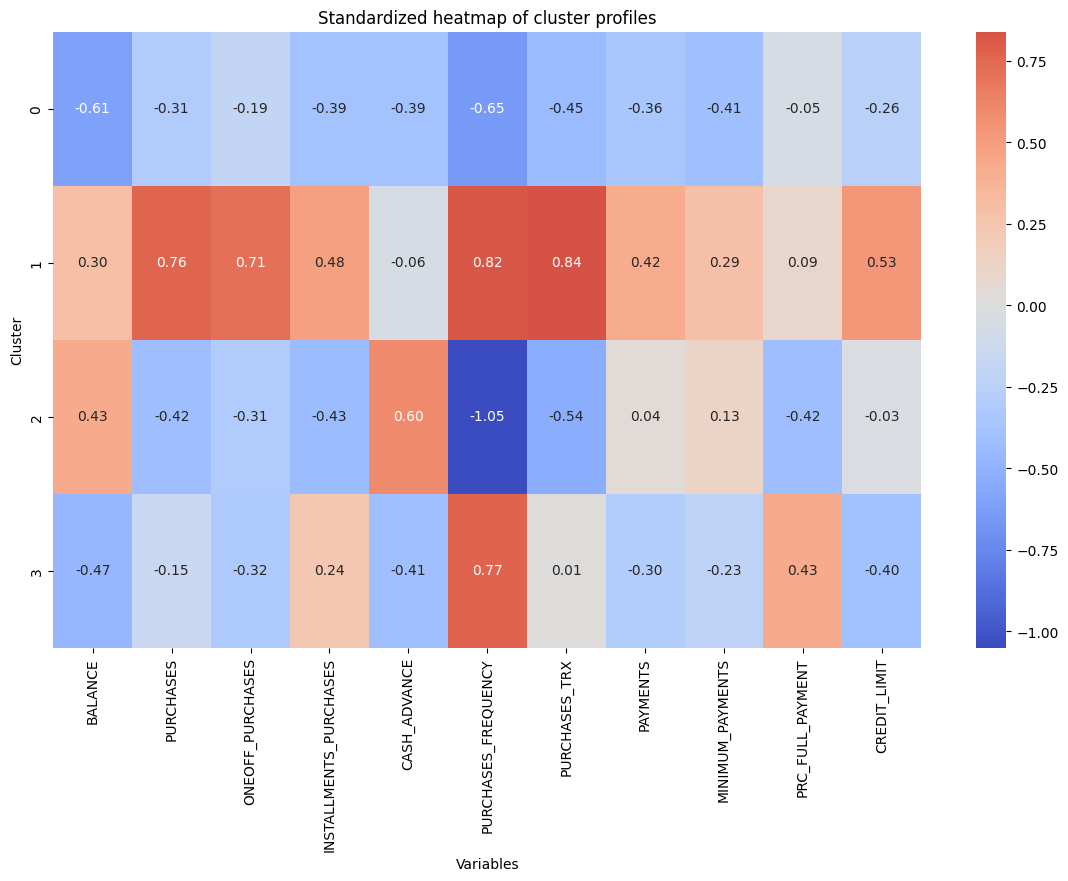

In [412]:
# Standardize the cluster averages to better compare the variables.
# Positive values indicate that the cluster is above the overall average.
# Negative values indicate that the cluster is below the overall average.
cluster_profile_z = ((cluster_profile_key - df_clustered[key_variables].mean()) / df_clustered[key_variables].std()).round(2)

plt.figure(figsize=(14, 8))
sns.heatmap(cluster_profile_z, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Standardized heatmap of cluster profiles")
plt.xlabel("Variables")
plt.ylabel("Cluster")
plt.show()

### Observations on the results

The standardized heatmap highlights the main differences between the clusters compared to the overall dataset average.  
Positive values indicate that the cluster shows above-average levels for the variable considered, while negative values indicate below-average levels.

**Cluster 1** stands out for above-average values in many variables related to activity and spending, such as purchases, one-off purchases, purchase frequency, number of transactions, payments, and credit limit, confirming it as the most active and potentially most profitable segment.  
**Cluster 2**, instead, shows above-average values mainly for cash advance and below-average values for purchase frequency, suggesting card usage more oriented toward cash advances than purchases.  
**Cluster 3** shows a greater tendency toward installment purchases and good usage frequency, while **Cluster 0** presents below-average values in most of the variables considered, representing the least active segment.


## Interpretative summary of the clusters

Based on the differences that emerged from the analysis of average values and from the graphical visualization, it is possible to assign each cluster a synthetic description.  
This classification makes it possible to translate the numerical results of clustering into customer profiles that are easier to interpret from a business and marketing perspective.

In [413]:
cluster_summary = pd.DataFrame({
    "Cluster": [0, 1, 2, 3],
    "Segment name": [
        "Low-activity customers",
        "High-spending and high-activity customers",
        "High cash advance usage customers",
        "Installment purchase-oriented customers"
    ],
    "Synthetic description": [
        "They show limited levels of balance, purchases, usage frequency, and payments.",
        "They represent the most dynamic group, with high purchase amounts, many transactions, higher payments, and a higher credit limit.",
        "They stand out for their high use of cash advances and low purchase activity.",
        "They use the card frequently and show a higher incidence of installment purchases."
    ]
})

cluster_summary


,Cluster,Segment name,Synthetic description
0,0,Low-activity customers,"They show limited levels of balance, purchases, usage frequency, and payments."
1,1,High-spending and high-activity customers,"They represent the most dynamic group, with high purchase amounts, many transactions, higher payments, and a higher credit limit."
2,2,High cash advance usage customers,They stand out for their high use of cash advances and low purchase activity.
3,3,Installment purchase-oriented customers,They use the card frequently and show a higher incidence of installment purchases.


### Observations on the results

The table summarizes the main profiles that emerged from the cluster analysis in a concise form.

In particular, Cluster 0 identifies low-activity customers, characterized by low levels of card usage and spending; Cluster 1 represents high-spending and high-activity customers, with high purchase amounts, many transactions, higher payments, and a higher credit limit; Cluster 2 includes customers who mainly rely on cash advances and show limited purchase activity; finally, Cluster 3 identifies installment purchase-oriented customers, characterized by frequent card usage and a higher incidence of installment purchases.

This classification makes it possible to translate the clustering results into concrete customer profiles, useful for guiding subsequent targeted marketing strategies.


## Customer distribution across clusters

In addition to describing the average characteristics of each group, it is also useful to analyze the distribution of customers across the different clusters.  
The size and percentage weight of each segment make it possible to assess the quantitative relevance of the identified groups and to understand which clusters have a greater impact on the overall customer base.

In [414]:
cluster_size = df_clustered["Cluster"].value_counts().sort_index()

cluster_distribution = pd.DataFrame({
    "Number of customers": cluster_size,
    "Percentage (%)": round(cluster_size / len(df_clustered) * 100, 2)
})

cluster_distribution

,Number of customers,Percentage (%)
Cluster,,
0,1510,16.87
1,2551,28.50
2,2727,30.47
3,2162,24.16


### Observations on the results

The distribution of customers across clusters shows that the identified groups have fairly balanced sizes, although with some differences.

Cluster 2 represents the largest segment, with 2,727 customers, equal to 30.47% of the total, followed by Cluster 1 with 2,551 customers (28.50%) and Cluster 3 with 2,162 customers (24.16%).

Cluster 0 is instead the least populated group, with 1,510 customers, corresponding to 16.87% of the dataset.

These results indicate that all segments have sufficient quantitative relevance for targeted marketing actions, while the low-activity customer group remains the smallest segment.



## Development of marketing strategies

After identifying and interpreting the customer clusters, the next step consists of translating the clustering results into targeted marketing strategies.  
The objective is to associate each segment with specific commercial actions, consistent with the spending behaviors, card usage patterns, and payment habits that emerged from the analysis.

In this section, for each cluster, the following will be defined:
- the synthetic profile of the segment;
- the marketing objective;
- the proposed strategy;
- the expected benefit for the company.

### Cluster 0 — Low-activity customers

This cluster includes customers with low spending levels, a reduced number of transactions, and limited use of the services linked to the credit card.  
They are therefore users with a low level of engagement, who may be inactive or may not fully exploit the product.

**Marketing objective:** increase card usage and reactivate customer engagement.

In [415]:
cluster0_strategy = pd.DataFrame({
    "Cluster": ["Cluster 0"],
    "Segment": ["Low-activity customers"],
    "Marketing objective": ["Increase card usage and reactivate customer engagement"],
    "Proposed actions": [
        "Offer reactivation cashback, limited-time promotions, and reward points programs when a minimum number of transactions is reached"
    ],
    "KPIs to monitor": [
        "Reactivation rate, average number of transactions per customer, increase in purchase frequency, and promotion adoption rate"
    ],
    "Expected benefit": [
        "Greater card usage, improved retention, and higher activation of customers with a low level of engagement"
    ]
})

cluster0_strategy

,Cluster,Segment,Marketing objective,Proposed actions,KPIs to monitor,Expected benefit
0,Cluster 0,Low-activity customers,Increase card usage and reactivate customer engagement,"Offer reactivation cashback, limited-time promotions, and reward points programs when a minimum number of transactions is reached","Reactivation rate, average number of transactions per customer, increase in purchase frequency, and promotion adoption rate","Greater card usage, improved retention, and higher activation of customers with a low level of engagement"


## Observations on the results

The analysis of **Cluster 0** therefore suggests the adoption of reactivation campaigns aimed at customers with low card usage.  
In particular, tools such as initial cashback, limited-time promotions, and reward points programs can encourage an increase in usage frequency and promote greater customer engagement.

From a business perspective, this segment represents a growth opportunity, since even a moderate increase in activity level could result in improved retention and an increase in the overall transaction volume.

### Cluster 1 — High-spending and high-activity customers

This cluster includes customers with high spending levels, a high number of transactions, higher payments, and a higher credit limit compared to the other segments.  
It is therefore the most active and potentially most profitable group, characterized by intensive product usage and an already consolidated relationship with the credit card.

**Marketing objective:** retain high-value customers, increase retention, and offer premium services or upgrade opportunities.


In [416]:
cluster1_strategy = pd.DataFrame({
    "Cluster": ["Cluster 1"],
    "Segment": ["High-spending and high-activity customers"],
    "Marketing objective": ["Retain high-value customers and offer premium services or upgrades"],
    "Proposed actions": [
        "Offer exclusive loyalty programs, premium benefits, personalized credit limit increases, and campaigns dedicated to higher value-added products or services"
    ],
    "KPIs to monitor": [
        "Retention rate, increase in spending volume, average transaction value, adoption of premium programs, and use of the credit limit increase"
    ],
    "Expected benefit": [
        "Greater retention of the most profitable customers, increased satisfaction, and stronger long-term value generated by the segment"
    ]
})

cluster1_strategy


,Cluster,Segment,Marketing objective,Proposed actions,KPIs to monitor,Expected benefit
0,Cluster 1,High-spending and high-activity customers,Retain high-value customers and offer premium services or upgrades,"Offer exclusive loyalty programs, premium benefits, personalized credit limit increases, and campaigns dedicated to higher value-added products or services","Retention rate, increase in spending volume, average transaction value, adoption of premium programs, and use of the credit limit increase","Greater retention of the most profitable customers, increased satisfaction, and stronger long-term value generated by the segment"


### Observations on the results

The analysis of **Cluster 1** identifies the most active and potentially most profitable segment of the customer portfolio.  
Since these customers show high spending levels, many transactions, higher payments, and a higher credit limit, strategies aimed at loyalty and relationship enhancement are particularly consistent with the cluster profile.

From a business perspective, this segment represents an opportunity to retain high-value customers, increase satisfaction, and strengthen the long-term value generated by the customer relationship.


### Cluster 2 — High cash advance usage customers

This cluster includes customers characterized by frequent use of cash advances and card usage that is less oriented toward traditional purchases.  
The segment may reflect a recurring need for immediate liquidity, as well as a lower tendency to use the card as a payment tool for ordinary consumption.

**Marketing objective:** propose financial solutions that are more suitable for the segment’s liquidity needs and encourage a more balanced use of the card.

In [417]:
cluster2_strategy = pd.DataFrame({
    "Cluster": ["Cluster 2"],
    "Segment": ["High cash advance usage customers"],
    "Marketing objective": ["Offer more suitable liquidity solutions and encourage more balanced card usage"],
    "Proposed actions": [
        "Offer complementary financial products, more structured credit solutions, and personalized communications that encourage greater card usage for purchases rather than cash advances"
    ],
    "KPIs to monitor": [
        "Reduction in cash advance frequency, reduction in the average cash advance amount, increase in card purchases, and adoption rate of alternative financial products"
    ],
    "Expected benefit": [
        "Greater alignment between customer financial needs and the company’s offering, improved user experience, and the possibility of expanding the commercial relationship"
    ]
})

cluster2_strategy

,Cluster,Segment,Marketing objective,Proposed actions,KPIs to monitor,Expected benefit
0,Cluster 2,High cash advance usage customers,Offer more suitable liquidity solutions and encourage more balanced card usage,"Offer complementary financial products, more structured credit solutions, and personalized communications that encourage greater card usage for purchases rather than cash advances","Reduction in cash advance frequency, reduction in the average cash advance amount, increase in card purchases, and adoption rate of alternative financial products","Greater alignment between customer financial needs and the company’s offering, improved user experience, and the possibility of expanding the commercial relationship"


### Observations on the results

The analysis of **Cluster 2** highlights a customer segment that frequently relies on cash advances, suggesting a recurring need for liquidity rather than card usage oriented toward purchases.  
For this reason, an effective strategy should not be limited to generally encouraging card usage, but should instead propose financial solutions that are more consistent with the needs of the segment.

From a business perspective, this approach can improve the quality of the customer relationship, increase the alignment between the financial profile and the commercial offering, and create cross-selling opportunities for products that are more suitable for liquidity needs.

### Cluster 3 — Installment purchase-oriented customers

This cluster includes customers who use the card frequently and show a particular tendency toward installment purchases.  
The segment therefore highlights an interest in more flexible payment methods, which allow spending to be spread over time.

**Marketing objective:** further encourage the use of installment payments and increase the volume of purchases made through this method.


In [418]:
cluster3_strategy = pd.DataFrame({
    "Cluster": ["Cluster 3"],
    "Segment": ["Installment purchase-oriented customers"],
    "Marketing objective": ["Encourage installment payments and increase purchase volume"],
    "Proposed actions": [
        "Offer promotions on installment purchases, facilitated payment plans, and dedicated offers on spending categories compatible with flexible repayment"
    ],
    "KPIs to monitor": [
        "Increase in installment purchases, average number of installment transactions, average purchase value, and adoption rate of flexible payment offers"
    ],
    "Expected benefit": [
        "Greater card usage for installment purchases, increased transactions, and stronger relationships with customers interested in flexible payment solutions"
    ]
})

cluster3_strategy


,Cluster,Segment,Marketing objective,Proposed actions,KPIs to monitor,Expected benefit
0,Cluster 3,Installment purchase-oriented customers,Encourage installment payments and increase purchase volume,"Offer promotions on installment purchases, facilitated payment plans, and dedicated offers on spending categories compatible with flexible repayment","Increase in installment purchases, average number of installment transactions, average purchase value, and adoption rate of flexible payment offers","Greater card usage for installment purchases, increased transactions, and stronger relationships with customers interested in flexible payment solutions"


### Observations on the results

The analysis of **Cluster 3** highlights a customer segment that shows a clear preference for flexible payment methods, particularly installment purchases.  
For this reason, strategies based on dedicated installment promotions, facilitated conditions, and offers on specific spending categories are particularly consistent with the cluster profile.

From a business perspective, this segment represents an opportunity to increase transaction volume and strengthen the relationship with customers who are already inclined to use deferred payment solutions.


## Summary of marketing strategies

Overall, the segmentation obtained allows **FinTech Solutions S.p.A.** to distinguish groups of customers with different behaviors in terms of spending, card usage, and payment methods.  
This subdivision makes it possible to define more targeted marketing strategies, moving beyond a uniform approach and allowing the company to adapt its actions to the specific characteristics of each segment.

In particular:
- low-activity customers can be engaged through reactivation campaigns;
- installment purchase-oriented customers can be enhanced with offers dedicated to payment flexibility;
- customers with high cash advance usage can be directed toward financial solutions that are more consistent with their liquidity needs;
- high-spending and high-activity customers can be retained through premium services and loyalty programs.

From a managerial perspective, this approach makes it possible to improve the effectiveness of promotional campaigns, increase customer satisfaction, optimize the allocation of commercial resources, and strengthen the value generated by the customer portfolio in the medium to long term.

In the next cell, a final model summary is therefore built, collecting the main technical and managerial information of the segmentation: cluster size, customer percentage, distinctive characteristics, and recommended marketing strategies.

In [419]:
# Settings to better display textual tables
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 200)

# 1. Cluster size
cluster_sizes = df_clustered["Cluster"].value_counts().sort_index()
cluster_percentages = (cluster_sizes / len(df_clustered) * 100).round(2)

# 2. Segment names consistent with the project interpretation
cluster_names_en = {
    0: "Low-activity customers",
    1: "High-spending and high-activity customers",
    2: "High cash advance usage customers",
    3: "Installment purchase-oriented customers"
}

# 3. Main characteristics of the segments
cluster_characteristics = {
    0: "Low spending levels, few transactions, and limited card usage.",
    1: "High spending levels, many transactions, higher payments, and greater payment capacity.",
    2: "High use of cash advances and lower orientation toward traditional purchases.",
    3: "Frequent card usage, with a particular tendency toward installment purchases."
}

# 4. Recommended marketing strategies
cluster_strategies = {
    0: "Reactivation campaigns, cashback, limited-time promotions, and reward points programs.",
    1: "Exclusive loyalty programs, premium benefits, personalized upgrades, and credit limit increases.",
    2: "Alternative financial solutions, liquidity products, and targeted communications to encourage more balanced card usage.",
    3: "Promotions on installment purchases, facilitated payment plans, and offers dedicated to repayment flexibility."
}

# 5. Key variables for the final technical summary
summary_variables = [
    "PURCHASES",
    "INSTALLMENTS_PURCHASES",
    "CASH_ADVANCE",
    "PURCHASES_FREQUENCY",
    "PURCHASES_TRX",
    "PRC_FULL_PAYMENT",
    "CREDIT_LIMIT"
]

# 6. Complete technical table of the clusters
technical_summary = df_clustered.groupby("Cluster")[summary_variables].mean().round(2)

technical_summary["Segment name"] = technical_summary.index.map(cluster_names_en)
technical_summary["Number of customers"] = cluster_sizes
technical_summary["Customer percentage (%)"] = cluster_percentages

technical_summary = technical_summary[
    [
        "Segment name",
        "Number of customers",
        "Customer percentage (%)",
        "PURCHASES",
        "INSTALLMENTS_PURCHASES",
        "CASH_ADVANCE",
        "PURCHASES_FREQUENCY",
        "PURCHASES_TRX",
        "PRC_FULL_PAYMENT",
        "CREDIT_LIMIT"
    ]
]

# 7. First technical table: cluster size and main economic values
technical_summary_spending = technical_summary[
    [
        "Segment name",
        "Number of customers",
        "Customer percentage (%)",
        "PURCHASES",
        "INSTALLMENTS_PURCHASES",
        "CASH_ADVANCE"
    ]
]

# 8. Second technical table: frequency, transactions, full payment, and credit limit
technical_summary_usage = technical_summary[
    [
        "Segment name",
        "PURCHASES_FREQUENCY",
        "PURCHASES_TRX",
        "PRC_FULL_PAYMENT",
        "CREDIT_LIMIT"
    ]
]

# 9. Managerial table with interpretation and marketing strategies
marketing_summary = pd.DataFrame({
    "Cluster": [0, 1, 2, 3],
    "Segment name": [cluster_names_en[i] for i in range(4)],
    "Main characteristics": [cluster_characteristics[i] for i in range(4)],
    "Recommended marketing strategy": [cluster_strategies[i] for i in range(4)]
})

marketing_summary = marketing_summary.set_index("Cluster")

# 10. Silhouette score of the final model
silhouette_final = silhouette_score(df_scaled, final_labels)

# 11. Final model output
print("FINAL SUMMARY OF THE SEGMENTATION MODEL")
print("-" * 60)
print(f"Total number of customers: {len(df_clustered)}")
print("Final number of selected clusters: 4")
print(f"Silhouette score of the final model (k=4): {silhouette_final:.4f}")

print("\nTechnical table 1 - Cluster size and main economic values:\n")
display(technical_summary_spending)

print("\nTechnical table 2 - Usage frequency, transactions, full payment, and credit limit:\n")
display(technical_summary_usage)

print("\nManagerial table with interpretation and marketing strategies:\n")
display(marketing_summary)


FINAL SUMMARY OF THE SEGMENTATION MODEL
------------------------------------------------------------
Total number of customers: 8950
Final number of selected clusters: 4
Silhouette score of the final model (k=4): 0.2242

Technical table 1 - Cluster size and main economic values:



,Segment name,Number of customers,Customer percentage (%),PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE
Cluster,,,,,,
0,Low-activity customers,1510,16.87,343.23,62.04,151.81
1,High-spending and high-activity customers,2551,28.50,2625.24,849.12,854.50
2,High cash advance usage customers,2727,30.47,100.98,22.98,2231.09
3,Installment purchase-oriented customers,2162,24.16,689.51,627.48,123.79



Technical table 2 - Usage frequency, transactions, full payment, and credit limit:



,Segment name,PURCHASES_FREQUENCY,PURCHASES_TRX,PRC_FULL_PAYMENT,CREDIT_LIMIT
Cluster,,,,,
0,Low-activity customers,0.23,3.60,0.14,3533.63
1,High-spending and high-activity customers,0.82,35.56,0.18,6408.76
2,High cash advance usage customers,0.07,1.20,0.03,4378.65
3,Installment purchase-oriented customers,0.80,14.92,0.28,3052.14



Managerial table with interpretation and marketing strategies:



,Segment name,Main characteristics,Recommended marketing strategy
Cluster,,,
0,Low-activity customers,"Low spending levels, few transactions, and limited card usage.","Reactivation campaigns, cashback, limited-time promotions, and reward points programs."
1,High-spending and high-activity customers,"High spending levels, many transactions, higher payments, and greater payment capacity.","Exclusive loyalty programs, premium benefits, personalized upgrades, and credit limit increases."
2,High cash advance usage customers,High use of cash advances and lower orientation toward traditional purchases.,"Alternative financial solutions, liquidity products, and targeted communications to encourage more balanced card usage."
3,Installment purchase-oriented customers,"Frequent card usage, with a particular tendency toward installment purchases.","Promotions on installment purchases, facilitated payment plans, and offers dedicated to repayment flexibility."


## Operational output for marketing campaigns

To make the segmentation usable also from an operational perspective, a final table is created that associates each customer with their cluster and the corresponding descriptive segment name.

This table represents a possible output to provide to the marketing team in order to plan targeted campaigns for the different identified customer groups.

The final table is exported as a CSV file using `OUTPUT_PATH`, so that the output is saved in the same folder as the dataset and can be easily reused for marketing activities.


In [420]:
segmented_customers = df_clustered[["CUST_ID", "Cluster", "Cluster_Name"]].copy()

segmented_customers = segmented_customers.rename(columns={
    "Cluster_Name": "Segment name"
})

display(segmented_customers.head(10))

OUTPUT_PATH = DATA_PATH.parent / "segmented_customers_marketing.csv"

segmented_customers.to_csv(OUTPUT_PATH, index=False)

print(f"Segmented customer file saved to: {OUTPUT_PATH.resolve()}")


,CUST_ID,Cluster,Segment name
0,C10001,0,Low-activity customers
1,C10002,2,High cash advance usage customers
2,C10003,1,High-spending and high-activity customers
3,C10004,0,Low-activity customers
4,C10005,0,Low-activity customers
5,C10006,3,Installment purchase-oriented customers
6,C10007,1,High-spending and high-activity customers
7,C10008,3,Installment purchase-oriented customers
8,C10009,1,High-spending and high-activity customers
9,C10010,0,Low-activity customers


Segmented customer file saved to: /content/segmented_customers_marketing.csv


## Final conclusions

The project made it possible to develop a customer segmentation model based on credit card usage behavior, with the aim of supporting **FinTech Solutions S.p.A.** in defining more targeted and effective marketing campaigns.

After an initial phase of exploratory data analysis and preprocessing, the dataset was processed through a clustering procedure using **K-Means**.  
The final solution with **4 clusters** made it possible to obtain interpretable and operationally coherent segments, despite a moderate separation between the groups, as indicated by a silhouette score of **0.2242**.

The analysis highlighted four main customer profiles:
- a segment of **low-activity customers**, characterized by limited card usage;
- a group of **installment purchase-oriented customers**, interested in more flexible payment methods;
- a segment of **high cash advance usage customers**, more oriented toward liquidity needs;
- a group of **high-spending and high-activity customers**, representing the most dynamic and potentially most profitable segment.

From a business perspective, these results show how segmentation can represent a strategic tool to personalize offers, improve the effectiveness of promotional campaigns, optimize the allocation of commercial resources, and strengthen the relationship with different customer segments.

In conclusion, the project demonstrates that clustering techniques, when accompanied by a proper interpretation of the results, can provide valuable support for marketing decisions, transforming customer behavioral data into concrete operational insights useful for business growth.
